# Non-pregnant anemia prevalence and DALYs averted by fortification

We take a "multiplication model" approach here, shifting continuous hemoglobin (as estimated
by GBD) and seeing what impact that has on anemia.

It's important to note that we directly use hemoglobin estimates, which are the first step
of the GBD anemia estimation pipeline. The risks and causes that are related to anemia are
all calculated downstream from this.

In [1]:
import gbd_mapping
import risk_distributions
import pathlib
import pandas as pd, numpy as np
import vivarium_inputs
from vivarium_inputs import utility_data, globals as vi_globals, utilities as vi_utils
from vivarium_gbd_access import gbd
import os, contextlib, warnings, loguru
from lsff_utils import config_utils
from lsff_utils.hemoglobin_distribution import hemoglobin_cdf_from_mean_sd

from vivarium_inputs.validation.raw import DataDoesNotExistError, DataAbnormalError
from tqdm.notebook import tqdm

Config: 'input_data:
    cache_data:
        base: True
    intermediary_data_cache_path:
        base: /share/scratch/users/{username}/cache'
Cache Dir: '/share/scratch/users/zmbc/cache'


In [2]:
pd.set_option("display.max_columns", 30)

In [3]:
warnings.simplefilter(action="ignore", category=pd.errors.PerformanceWarning)

In [4]:
location = "ethiopia"
vehicle = "salt"

In [5]:
# Parameters
location = "ethiopia"
vehicle = "salt"

In [6]:
intervention_scenarios = config_utils.get_config()["custom_intervention_scenarios"].get(
    location, ["intervention"]
)
intervention_scenarios

['intervention_25_nrv', 'intervention_100_nrv']

## Setup and scenarios

In [7]:
DRAWS = [
    f"draw_{i}" for i in range(500)
]  # NOTE: Some GBD 2021 things return 1,000 but others don't

In [8]:
effective_coverage_baseline = pd.read_csv(
    f"../0100_data_prep/results/folate/{vehicle}/baseline_fortification/effective_coverage/{location}.csv"
)
assert (effective_coverage_baseline.vehicle_name == vehicle).all()
effective_coverage_baseline = effective_coverage_baseline.drop(columns=["vehicle_name"])
effective_coverage_baseline

,wealth_quintile,value
0,1,0.0
1,2,0.0
2,3,0.0
3,4,0.0
4,5,0.0


In [9]:
def expand(df):
    for col in sorted(list(set(df.columns) - {"value"})):
        if df[col].isnull().any():
            df = pd.concat(
                [
                    df[df[col].notnull()],
                    *[
                        df[df[col].isnull()].assign(**{col: value})
                        for value in df[df[col].notnull()][col].unique()
                    ],
                ]
            )

    return df

In [10]:
for col, fill_value in [("age_start", 0), ("age_end", 125)]:
    if col not in effective_coverage_baseline.columns:
        effective_coverage_baseline[col] = fill_value
    else:
        effective_coverage_baseline[col] = effective_coverage_baseline[col].fillna(
            fill_value
        )

In [11]:
effective_coverage_baseline = expand(effective_coverage_baseline)
effective_coverage_baseline

,wealth_quintile,value,age_start,age_end
0,1,0.0,0,125
1,2,0.0,0,125
2,3,0.0,0,125
3,4,0.0,0,125
4,5,0.0,0,125


In [12]:
effective_coverage_intervention = pd.concat(
    [
        pd.read_csv(
            f"../0100_data_prep/results/folate/{vehicle}/{intervention_scenario}/intervention_fortification/effective_coverage/{location}.csv"
        ).assign(scenario=intervention_scenario)
        for intervention_scenario in intervention_scenarios
    ]
)
assert (effective_coverage_intervention.vehicle_name == vehicle).all()
effective_coverage_intervention = effective_coverage_intervention.drop(
    columns=["vehicle_name"]
)
effective_coverage_intervention

,wealth_quintile,sex,value,scenario
0,1,Female,0.6984,intervention_25_nrv
1,1,Male,0.6984,intervention_25_nrv
2,2,Female,0.6984,intervention_25_nrv
3,2,Male,0.6984,intervention_25_nrv
4,3,Female,0.6984,intervention_25_nrv
5,3,Male,0.6984,intervention_25_nrv
6,4,Female,0.6984,intervention_25_nrv
7,4,Male,0.6984,intervention_25_nrv
8,5,Female,0.6984,intervention_25_nrv
9,5,Male,0.6984,intervention_25_nrv


In [13]:
for col, fill_value in [("age_start", 0), ("age_end", 125)]:
    if col not in effective_coverage_intervention.columns:
        effective_coverage_intervention[col] = fill_value
    else:
        effective_coverage_intervention[col] = effective_coverage_intervention[
            col
        ].fillna(fill_value)

In [14]:
effective_coverage_intervention = expand(effective_coverage_intervention)
effective_coverage_intervention

,wealth_quintile,sex,value,scenario,age_start,age_end
0,1,Female,0.6984,intervention_25_nrv,0,125
1,1,Male,0.6984,intervention_25_nrv,0,125
2,2,Female,0.6984,intervention_25_nrv,0,125
3,2,Male,0.6984,intervention_25_nrv,0,125
4,3,Female,0.6984,intervention_25_nrv,0,125
5,3,Male,0.6984,intervention_25_nrv,0,125
6,4,Female,0.6984,intervention_25_nrv,0,125
7,4,Male,0.6984,intervention_25_nrv,0,125
8,5,Female,0.6984,intervention_25_nrv,0,125
9,5,Male,0.6984,intervention_25_nrv,0,125


In [15]:
population = pd.read_csv(
    f"../0100_data_prep/results/population/stratified/{location}.csv"
)

In [16]:
non_pregnant_pop = population.pipe(lambda df: df[df.pregnant == "not_pregnant"]).drop(
    columns="pregnant"
)
non_pregnant_pop = non_pregnant_pop.set_index(
    [c for c in non_pregnant_pop.columns if c != "value"]
).value
non_pregnant_pop

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  7729.330504
                               2                  7026.085890
                               3                  6642.401601
                               4                  5956.884779
                               5                  4774.758589
                                                     ...     
Male    95.0       125.000000  1                   659.578610
                               2                   690.099645
                               3                   716.289850
                               4                   757.897451
                               5                   664.219250
Name: value, Length: 250, dtype: float64

In [17]:
population.set_index(["sex", "age_start", "age_end"]).loc[
    ("Female", 25, 30)
].value.sum()

4610923.175812704

In [18]:
non_pregnant_pop.loc[("Female", 25, 30)][1]

573654.3130266926

In [19]:
non_pregnant_pop.loc[("Female", 25, 30)].sum()

3723713.935661219

In [20]:
population_age_groups = (
    non_pregnant_pop.reset_index()[["age_start", "age_end"]]
    .drop_duplicates()
    .sort_values("age_start")
)
population_age_groups

,age_start,age_end
0,0.000000,0.019178
5,0.019178,0.076712
10,0.076712,0.500000
15,0.500000,1.000000
20,1.000000,2.000000
25,2.000000,5.000000
30,5.000000,10.000000
35,10.000000,15.000000
40,15.000000,20.000000
45,20.000000,25.000000


In [21]:
def map_to_population_age_groups(df):
    result = (
        population_age_groups.merge(df, how="cross", suffixes=("", "_orig"))
        .pipe(
            lambda df: df[
                (df.age_end <= df.age_end_orig) & (df.age_start >= df.age_start_orig)
            ]
        )
        .drop(columns=["age_start_orig", "age_end_orig"])
    )
    return result

In [22]:
effective_coverage_baseline = (
    map_to_population_age_groups(effective_coverage_baseline)
    .set_index([c for c in effective_coverage_baseline.columns if c != "value"])
    .value
)
effective_coverage_intervention = (
    map_to_population_age_groups(effective_coverage_intervention)
    .set_index([c for c in effective_coverage_intervention.columns if c != "value"])
    .value
)

In [23]:
if "sex" not in effective_coverage_baseline.index.names:
    # Assume does not vary
    effective_coverage_baseline = pd.concat(
        [
            effective_coverage_baseline.reset_index()
            .assign(sex="Female")
            .set_index(["wealth_quintile", "sex", "age_start", "age_end"])
            .value,
            effective_coverage_baseline.reset_index()
            .assign(sex="Male")
            .set_index(["wealth_quintile", "sex", "age_start", "age_end"])
            .value,
        ]
    )

In [24]:
effective_coverage_baseline = (
    effective_coverage_baseline.reset_index()
    .set_index(["sex", "age_start", "age_end", "wealth_quintile"])
    .value
)

In [25]:
if "sex" not in effective_coverage_intervention.index.names:
    # Assume does not vary
    effective_coverage_intervention = pd.concat(
        [
            effective_coverage_intervention.reset_index()
            .assign(sex="Female")
            .set_index(["sex", "age_start", "age_end", "wealth_quintile"])
            .value,
            effective_coverage_intervention.reset_index()
            .assign(sex="Male")
            .set_index(["sex", "age_start", "age_end", "wealth_quintile"])
            .value,
        ]
    )

In [26]:
effective_coverage_intervention = (
    effective_coverage_intervention.reset_index()
    # TODO: Make this clearer. This is just reordering.
    .set_index(["sex", "age_start", "age_end", "wealth_quintile", "scenario"]).value
)

In [27]:
example_sex = "Female"
example_age_start = 25
example_age_end = 30
example_wealth_quintile = 1
example_scenario = effective_coverage_intervention.index.get_level_values("scenario")[0]
example_tuple = (
    example_sex,
    example_age_start,
    example_age_end,
    example_wealth_quintile,
)

In [28]:
effective_coverage_baseline.loc[example_tuple]

0.0

In [29]:
effective_coverage_intervention.loc[example_tuple]

scenario
intervention_25_nrv     0.6984
intervention_100_nrv    0.6984
Name: value, dtype: float64

In [30]:
def reshape_to_vivarium_format(df, location):
    df = vi_utils.reshape(df, value_cols=[c for c in df.columns if "draw_" in c])
    df = vi_utils.scrub_gbd_conventions(df, location)
    df = vi_utils.split_interval(df, interval_column="age", split_column_prefix="age")
    df = vi_utils.split_interval(df, interval_column="year", split_column_prefix="year")
    df = vi_utils.sort_hierarchical_data(df)
    df.index = df.index.droplevel("location")
    return df

## Pull GBD hemoglobin distributions

In [31]:
me_ids = {
    "hemoglobin_mean": 10487,
    "hemoglobin_sd": 10488,
}

In [32]:
def get_modelable_entity_draws(me_id, location):
    location_id = utility_data.get_location_id(location.title())
    result = gbd.get_modelable_entity_draws(
        me_id=me_id, location_id=location_id, year_id=2021
    )
    return (
        reshape_to_vivarium_format(result, location.title())
        .droplevel(
            [
                "year_start",
                "year_end",
                "measure_id",
                "metric_id",
                "model_version_id",
                "modelable_entity_id",
            ]
        )[DRAWS]
        .copy()
    )

In [33]:
hgb_mean = get_modelable_entity_draws(me_ids["hemoglobin_mean"], location)
hgb_mean

draw_0      draw_1      draw_2      draw_3  \
sex    age_start age_end                                                      
Female 0.000000  0.019178    147.585091  144.050853  144.544789  146.305834   
       0.019178  0.076712    121.215820  123.651977  122.089756  125.087892   
       0.076712  0.500000    105.983816  105.845980  107.447861  106.734229   
       0.500000  1.000000    102.753236  104.270147  104.936865   99.948709   
       1.000000  2.000000    106.991554  106.080566  106.204040  104.916779   
       2.000000  5.000000    108.677603  108.552689  109.931552  109.774444   
       5.000000  10.000000   116.300183  121.577774  117.447603  116.378668   
       10.000000 15.000000   129.559018  126.813493  129.631823  128.673369   
       15.000000 20.000000   131.388516  133.268587  132.337618  131.970494   
       20.000000 25.000000   135.608698  131.737999  131.087926  129.454020   
       25.000000 30.000000   129.918843  130.526807  131.072618  130.206652   
       30.000000 35.000000   132.531208  130.580315  130.842620  131.267471   
       35.000000 40.000000   131.207934  132.825193  132.725543  129.854480   
       40.000000 45.000000   131.186942  130.468479  132.251951  130.745780   
       45.000000 50.000000   129.673686  128.608635  129.666011  132.575538   
       50.000000 55.000000   131.098297  129.389300  132.448192  131.277509   
       55.000000 60.000000   131.139861  129.252505  128.846876  130.170660   
       60.000000 65.000000   130.097548  132.519452  128.648950  133.381253   
       65.000000 70.000000   130.302080  131.044748  129.486370  132.214205   
       70.000000 75.000000   133.033216  132.961533  132.072924  130.306302   
       75.000000 80.000000   128.566111  129.731834  132.596496  127.848579   
       80.000000 85.000000   126.756619  128.821456  128.943629  126.552517   
       85.000000 90.000000   122.887726  124.281227  127.915631  124.348853   
       90.000000 95.000000   116.796039  111.406964  112.452098  114.838757   
       95.000000 125.000000  107.246251  105.499757  105.559896  108.019375   
Male   0.000000  0.019178    151.101165  149.756534  153.445466  149.698045   
       0.019178  0.076712    122.796148  124.645304  121.549976  120.195792   
       0.076712  0.500000    105.066701  103.976125  100.770438  103.387078   
       0.500000  1.000000    102.747076  102.185730  100.610623  100.690625   
       1.000000  2.000000    101.468342  102.998648  103.832031  102.648926   
       2.000000  5.000000    106.655953  111.330089  106.872511  109.810769   
       5.000000  10.000000   118.681415  116.051181  115.686651  118.847217   
       10.000000 15.000000   137.521019  133.131630  134.142525  127.505981   
       15.000000 20.000000   148.299665  145.689996  144.377498  149.530034   
       20.000000 25.000000   152.600688  152.739227  153.726197  151.933764   
       25.000000 30.000000   155.422791  152.568694  151.105753  150.049353   
       30.000000 35.000000   154.888331  152.469951  153.850890  151.860678   
       35.000000 40.000000   152.912030  153.000282  150.226230  147.348133   
       40.000000 45.000000   147.661031  149.735868  143.930102  145.981340   
       45.000000 50.000000   143.233856  148.008479  146.754942  149.717366   
       50.000000 55.000000   149.099850  142.418117  141.290350  144.463940   
       55.000000 60.000000   145.258865  145.210064  144.898126  144.132301   
       60.000000 65.000000   139.977504  146.597275  149.508425  144.880438   
       65.000000 70.000000   149.724483  146.032140  146.300235  142.189521   
       70.000000 75.000000   148.563721  140.066788  143.124604  140.427923   
       75.000000 80.000000   137.715983  135.292185  144.816445  138.559470   
       80.000000 85.000000   132.921945  137.015262  144.815700  138.590908   
       85.000000 90.000000   129.487461  131.394793  131.621777  130.216618   
       90.000000 95.000000   113.800674  114.110861  116.863505  113.299789   
    

In [34]:
hgb_mean.loc[("Female", 25, 30)].mean()

130.40717661811937

In [35]:
hemoglobin_mean_disparities = pd.read_csv(
    f"../0100_data_prep/results/hemoglobin/mean_disparities/{location}.csv"
)
hemoglobin_mean_disparities = (
    map_to_population_age_groups(
        hemoglobin_mean_disparities[
            hemoglobin_mean_disparities.pregnant == "not_pregnant"
        ].drop(columns=["pregnant"])
    )
    .set_index(["sex", "age_start", "age_end", "wealth_quintile"])
    .value
)
hemoglobin_mean_disparities

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  100.844346
                               2                  104.929413
                               3                  108.144135
                               4                  106.092684
                               5                  110.229853
                                                     ...    
Male    95.0       125.000000  1                  124.952266
                               2                  128.293821
                               3                  129.201329
                               4                  130.193045
                               5                  131.983786
Name: value, Length: 250, dtype: float64

In [36]:
wealth_quintile_probabilities = pd.read_csv(
    f"../0100_data_prep/results/wealth_quintile_probabilities/{location}.csv"
)
wealth_quintile_probabilities

,sex,age_start,age_end,pregnant,1,2,3,4,5
0,Female,0.0,5.0,not_pregnant,0.240568,0.218680,0.206739,0.185403,0.148610
1,Female,5.0,15.0,not_pregnant,0.219482,0.209157,0.210067,0.207411,0.153883
2,Female,15.0,30.0,not_pregnant,0.154054,0.173552,0.180132,0.193390,0.298871
3,Female,15.0,30.0,pregnant,0.214447,0.257398,0.173152,0.167345,0.187658
4,Female,30.0,50.0,not_pregnant,0.176930,0.178372,0.198273,0.205845,0.240580
5,Female,30.0,50.0,pregnant,0.250120,0.185543,0.217769,0.191428,0.155140
6,Female,50.0,125.0,not_pregnant,0.205491,0.204239,0.195294,0.199461,0.195515
7,Male,0.0,5.0,not_pregnant,0.236076,0.239462,0.208587,0.173674,0.142200
8,Male,5.0,15.0,not_pregnant,0.226779,0.210595,0.205277,0.206115,0.151234
9,Male,15.0,30.0,not_pregnant,0.157551,0.173962,0.186354,0.221764,0.260370


In [37]:
wealth_quintile_probabilities = map_to_population_age_groups(
    wealth_quintile_probabilities[
        wealth_quintile_probabilities.pregnant == "not_pregnant"
    ].drop(columns=["pregnant"])
).set_index(["sex", "age_start", "age_end"])
wealth_quintile_probabilities.columns.name = "wealth_quintile"
wealth_quintile_probabilities = wealth_quintile_probabilities.stack()
# TODO: Store wealth quintile probabilities without using numbers as columns
wealth_quintile_probabilities = (
    wealth_quintile_probabilities.rename("value")
    .reset_index()
    .assign(wealth_quintile=lambda df: df.wealth_quintile.astype(int))
    .set_index(wealth_quintile_probabilities.index.names)
    .value
)
wealth_quintile_probabilities

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  0.240568
                               2                  0.218680
                               3                  0.206739
                               4                  0.185403
                               5                  0.148610
                                                    ...   
Male    95.0       125.000000  1                  0.189095
                               2                  0.197845
                               3                  0.205353
                               4                  0.217282
                               5                  0.190425
Name: value, Length: 250, dtype: float64

In [38]:
assert np.allclose(
    wealth_quintile_probabilities.groupby(["sex", "age_start", "age_end"]).sum(), 1.0
)

In [39]:
def distribute_by_disparities(df, disparities):
    pre_disparity_groups = (
        df.mul(wealth_quintile_probabilities, axis=0)
        .groupby([c for c in df.index.names if c != "wealth_quintile"])
        .sum()
    )
    print("Before distributing by disparities:")
    display(pre_disparity_groups)

    df = df.mul(disparities, axis=0)

    scale_factor = (
        pre_disparity_groups
        / df.mul(wealth_quintile_probabilities, axis=0)
        .groupby([c for c in df.index.names if c != "wealth_quintile"])
        .sum()
    )
    print(f"Scale factor: {scale_factor}")

    df = df * scale_factor

    assert np.allclose(
        df.mul(wealth_quintile_probabilities, axis=0)
        .groupby([c for c in df.index.names if c != "wealth_quintile"])
        .sum(),
        pre_disparity_groups,
    )

    return df

In [40]:
hgb_mean = distribute_by_disparities(hgb_mean, hemoglobin_mean_disparities)

Before distributing by disparities:


draw_0      draw_1      draw_2      draw_3  \
sex    age_start age_end                                                      
Female 0.000000  0.019178    147.585091  144.050853  144.544789  146.305834   
       0.019178  0.076712    121.215820  123.651977  122.089756  125.087892   
       0.076712  0.500000    105.983816  105.845980  107.447861  106.734229   
       0.500000  1.000000    102.753236  104.270147  104.936865   99.948709   
       1.000000  2.000000    106.991554  106.080566  106.204040  104.916779   
       2.000000  5.000000    108.677603  108.552689  109.931552  109.774444   
       5.000000  10.000000   116.300183  121.577774  117.447603  116.378668   
       10.000000 15.000000   129.559018  126.813493  129.631823  128.673369   
       15.000000 20.000000   131.388516  133.268587  132.337618  131.970494   
       20.000000 25.000000   135.608698  131.737999  131.087926  129.454020   
       25.000000 30.000000   129.918843  130.526807  131.072618  130.206652   
       30.000000 35.000000   132.531208  130.580315  130.842620  131.267471   
       35.000000 40.000000   131.207934  132.825193  132.725543  129.854480   
       40.000000 45.000000   131.186942  130.468479  132.251951  130.745780   
       45.000000 50.000000   129.673686  128.608635  129.666011  132.575538   
       50.000000 55.000000   131.098297  129.389300  132.448192  131.277509   
       55.000000 60.000000   131.139861  129.252505  128.846876  130.170660   
       60.000000 65.000000   130.097548  132.519452  128.648950  133.381253   
       65.000000 70.000000   130.302080  131.044748  129.486370  132.214205   
       70.000000 75.000000   133.033216  132.961533  132.072924  130.306302   
       75.000000 80.000000   128.566111  129.731834  132.596496  127.848579   
       80.000000 85.000000   126.756619  128.821456  128.943629  126.552517   
       85.000000 90.000000   122.887726  124.281227  127.915631  124.348853   
       90.000000 95.000000   116.796039  111.406964  112.452098  114.838757   
       95.000000 125.000000  107.246251  105.499757  105.559896  108.019375   
Male   0.000000  0.019178    151.101165  149.756534  153.445466  149.698045   
       0.019178  0.076712    122.796148  124.645304  121.549976  120.195792   
       0.076712  0.500000    105.066701  103.976125  100.770438  103.387078   
       0.500000  1.000000    102.747076  102.185730  100.610623  100.690625   
       1.000000  2.000000    101.468342  102.998648  103.832031  102.648926   
       2.000000  5.000000    106.655953  111.330089  106.872511  109.810769   
       5.000000  10.000000   118.681415  116.051181  115.686651  118.847217   
       10.000000 15.000000   137.521019  133.131630  134.142525  127.505981   
       15.000000 20.000000   148.299665  145.689996  144.377498  149.530034   
       20.000000 25.000000   152.600688  152.739227  153.726197  151.933764   
       25.000000 30.000000   155.422791  152.568694  151.105753  150.049353   
       30.000000 35.000000   154.888331  152.469951  153.850890  151.860678   
       35.000000 40.000000   152.912030  153.000282  150.226230  147.348133   
       40.000000 45.000000   147.661031  149.735868  143.930102  145.981340   
       45.000000 50.000000   143.233856  148.008479  146.754942  149.717366   
       50.000000 55.000000   149.099850  142.418117  141.290350  144.463940   
       55.000000 60.000000   145.258865  145.210064  144.898126  144.132301   
       60.000000 65.000000   139.977504  146.597275  149.508425  144.880438   
       65.000000 70.000000   149.724483  146.032140  146.300235  142.189521   
       70.000000 75.000000   148.563721  140.066788  143.124604  140.427923   
       75.000000 80.000000   137.715983  135.292185  144.816445  138.559470   
       80.000000 85.000000   132.921945  137.015262  144.815700  138.590908   
       85.000000 90.000000   129.487461  131.394793  131.621777  130.216618   
       90.000000 95.000000   113.800674  114.110861  116.863505  113.299789   
    

Scale factor:                                draw_0    draw_1    draw_2    draw_3    draw_4  \
sex    age_start age_end                                                        
Female 0.000000  0.019178    0.009468  0.009468  0.009468  0.009468  0.009468   
       0.019178  0.076712    0.009468  0.009468  0.009468  0.009468  0.009468   
       0.076712  0.500000    0.009468  0.009468  0.009468  0.009468  0.009468   
       0.500000  1.000000    0.009468  0.009468  0.009468  0.009468  0.009468   
       1.000000  2.000000    0.009468  0.009468  0.009468  0.009468  0.009468   
       2.000000  5.000000    0.009468  0.009468  0.009468  0.009468  0.009468   
       5.000000  10.000000   0.008530  0.008530  0.008530  0.008530  0.008530   
       10.000000 15.000000   0.008530  0.008530  0.008530  0.008530  0.008530   
       15.000000 20.000000   0.007727  0.007727  0.007727  0.007727  0.007727   
       20.000000 25.000000   0.007727  0.007727  0.007727  0.007727  0.007727   
       25.0000

In [41]:
hgb_mean.columns.name = "draw"
hgb_mean = hgb_mean.stack().rename("mean")

In [42]:
hgb_sd = get_modelable_entity_draws(me_ids["hemoglobin_sd"], location)
hgb_sd

draw_0     draw_1     draw_2     draw_3  \
sex    age_start age_end                                                  
Female 0.000000  0.019178    17.417692  16.914154  17.322611  19.639630   
       0.019178  0.076712    31.920333  27.327325  31.515297  20.851676   
       0.076712  0.500000    15.860758  18.973759  19.061570  18.182488   
       0.500000  1.000000    13.918435  15.417598  19.623018  14.750577   
       1.000000  2.000000    16.601564  19.352545  18.908730  18.772105   
       2.000000  5.000000    17.762785  15.487025  18.722729  14.460074   
       5.000000  10.000000   10.014566  13.074177  12.333958   8.577542   
       10.000000 15.000000   14.536030  13.574599  16.049481  15.001941   
       15.000000 20.000000   16.179113  16.422278  17.248025  15.834593   
       20.000000 25.000000   23.456504  17.101074  17.594955  15.239035   
       25.000000 30.000000   17.030593  17.203541  17.114201  17.326694   
       30.000000 35.000000   18.671479  17.444062  18.620547  17.239894   
       35.000000 40.000000   15.699411  17.399317  15.892947  15.417309   
       40.000000 45.000000   18.492651  16.845740  16.942991  17.133601   
       45.000000 50.000000   14.163051  14.230783  15.477290  17.086612   
       50.000000 55.000000   14.129455  13.087479  16.779090  16.220590   
       55.000000 60.000000   16.332436  13.030082  16.487002  13.493311   
       60.000000 65.000000   17.505808  16.601904  13.094085  15.822932   
       65.000000 70.000000   16.158464  16.849607  13.438869  14.583464   
       70.000000 75.000000   16.401766  17.022380  16.739874  15.784032   
       75.000000 80.000000   13.302621  15.683313  17.333250  12.770549   
       80.000000 85.000000   11.288751  19.133847  21.020591  14.496786   
       85.000000 90.000000   12.697120  16.427871  19.736057  12.385962   
       90.000000 95.000000   13.554223   7.969305  11.368052   5.910966   
       95.000000 125.000000  18.820953  19.877225  24.089332  18.066680   
Male   0.000000  0.019178    10.392527   8.861671   4.109368   8.362214   
       0.019178  0.076712    25.626687  23.799057  28.704530  35.583950   
       0.076712  0.500000    15.614490  11.362138  13.465594  13.448084   
       0.500000  1.000000    20.471998  17.397986  15.690786  15.215331   
       1.000000  2.000000    16.272413  18.533042  17.122101  15.653096   
       2.000000  5.000000    12.776906  18.293480  13.247331  14.787737   
       5.000000  10.000000   10.820712   9.983296  12.738410   6.465963   
       10.000000 15.000000   19.679784  17.812862  16.045719  12.426496   
       15.000000 20.000000   16.850767  17.531371  15.225470  18.028911   
       20.000000 25.000000   17.749488  17.297797  18.110341  16.249330   
       25.000000 30.000000   19.210421  16.885185  16.270216  14.254649   
       30.000000 35.000000   19.248598  17.495043  17.162874  17.776280   
       35.000000 40.000000   18.534030  19.417879  16.920561  13.911337   
       40.000000 45.000000   16.552183  17.610507  14.815983  14.784899   
       45.000000 50.000000   16.725962  17.915847  18.287452  21.890030   
       50.000000 55.000000   18.470547  16.791428  14.051409  17.377770   
       55.000000 60.000000   16.749501  18.835426  18.935530  17.943830   
       60.000000 65.000000   11.347806  15.237524  20.107732  14.142434   
       65.000000 70.000000   20.502611  14.731810  15.434713  14.429983   
       70.000000 75.000000   20.511847  16.242973  14.388973  13.593509   
       75.000000 80.000000   16.548401  13.346246  22.409140  14.836697   
       80.000000 85.000000   14.625008  14.917377  19.197651  18.752531   
       85.000000 90.000000   14.460154  12.433468  13.013266  13.135733   
       90.000000 95.000000    8.514859  14.084146   7.942748  12.722668   
       95.000000 125.000000  13.628007  18.060974  20.353278  36.366511   

                                draw_4     draw_5     draw_6     draw_7  \
sex    age_start age_end                                

In [43]:
hemoglobin_sd_disparities = pd.read_csv(
    f"../0100_data_prep/results/hemoglobin/sd_disparities/{location}.csv"
)
hemoglobin_sd_disparities = (
    map_to_population_age_groups(
        hemoglobin_sd_disparities[
            hemoglobin_sd_disparities.pregnant == "not_pregnant"
        ].drop(columns=["pregnant"])
    )
    .set_index(["sex", "age_start", "age_end", "wealth_quintile"])
    .value
)
hemoglobin_sd_disparities

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  19.057214
                               2                  16.388767
                               3                  15.798272
                               4                  14.667368
                               5                  14.279931
                                                    ...    
Male    95.0       125.000000  1                  20.051752
                               2                  17.054204
                               3                  16.563451
                               4                  15.973793
                               5                  14.994380
Name: value, Length: 250, dtype: float64

In [44]:
hgb_sd = distribute_by_disparities(hgb_sd, hemoglobin_sd_disparities)
hgb_sd

Before distributing by disparities:


draw_0     draw_1     draw_2     draw_3  \
sex    age_start age_end                                                  
Female 0.000000  0.019178    17.417692  16.914154  17.322611  19.639630   
       0.019178  0.076712    31.920333  27.327325  31.515297  20.851676   
       0.076712  0.500000    15.860758  18.973759  19.061570  18.182488   
       0.500000  1.000000    13.918435  15.417598  19.623018  14.750577   
       1.000000  2.000000    16.601564  19.352545  18.908730  18.772105   
       2.000000  5.000000    17.762785  15.487025  18.722729  14.460074   
       5.000000  10.000000   10.014566  13.074177  12.333958   8.577542   
       10.000000 15.000000   14.536030  13.574599  16.049481  15.001941   
       15.000000 20.000000   16.179113  16.422278  17.248025  15.834593   
       20.000000 25.000000   23.456504  17.101074  17.594955  15.239035   
       25.000000 30.000000   17.030593  17.203541  17.114201  17.326694   
       30.000000 35.000000   18.671479  17.444062  18.620547  17.239894   
       35.000000 40.000000   15.699411  17.399317  15.892947  15.417309   
       40.000000 45.000000   18.492651  16.845740  16.942991  17.133601   
       45.000000 50.000000   14.163051  14.230783  15.477290  17.086612   
       50.000000 55.000000   14.129455  13.087479  16.779090  16.220590   
       55.000000 60.000000   16.332436  13.030082  16.487002  13.493311   
       60.000000 65.000000   17.505808  16.601904  13.094085  15.822932   
       65.000000 70.000000   16.158464  16.849607  13.438869  14.583464   
       70.000000 75.000000   16.401766  17.022380  16.739874  15.784032   
       75.000000 80.000000   13.302621  15.683313  17.333250  12.770549   
       80.000000 85.000000   11.288751  19.133847  21.020591  14.496786   
       85.000000 90.000000   12.697120  16.427871  19.736057  12.385962   
       90.000000 95.000000   13.554223   7.969305  11.368052   5.910966   
       95.000000 125.000000  18.820953  19.877225  24.089332  18.066680   
Male   0.000000  0.019178    10.392527   8.861671   4.109368   8.362214   
       0.019178  0.076712    25.626687  23.799057  28.704530  35.583950   
       0.076712  0.500000    15.614490  11.362138  13.465594  13.448084   
       0.500000  1.000000    20.471998  17.397986  15.690786  15.215331   
       1.000000  2.000000    16.272413  18.533042  17.122101  15.653096   
       2.000000  5.000000    12.776906  18.293480  13.247331  14.787737   
       5.000000  10.000000   10.820712   9.983296  12.738410   6.465963   
       10.000000 15.000000   19.679784  17.812862  16.045719  12.426496   
       15.000000 20.000000   16.850767  17.531371  15.225470  18.028911   
       20.000000 25.000000   17.749488  17.297797  18.110341  16.249330   
       25.000000 30.000000   19.210421  16.885185  16.270216  14.254649   
       30.000000 35.000000   19.248598  17.495043  17.162874  17.776280   
       35.000000 40.000000   18.534030  19.417879  16.920561  13.911337   
       40.000000 45.000000   16.552183  17.610507  14.815983  14.784899   
       45.000000 50.000000   16.725962  17.915847  18.287452  21.890030   
       50.000000 55.000000   18.470547  16.791428  14.051409  17.377770   
       55.000000 60.000000   16.749501  18.835426  18.935530  17.943830   
       60.000000 65.000000   11.347806  15.237524  20.107732  14.142434   
       65.000000 70.000000   20.502611  14.731810  15.434713  14.429983   
       70.000000 75.000000   20.511847  16.242973  14.388973  13.593509   
       75.000000 80.000000   16.548401  13.346246  22.409140  14.836697   
       80.000000 85.000000   14.625008  14.917377  19.197651  18.752531   
       85.000000 90.000000   14.460154  12.433468  13.013266  13.135733   
       90.000000 95.000000    8.514859  14.084146   7.942748  12.722668   
       95.000000 125.000000  13.628007  18.060974  20.353278  36.366511   

                                draw_4     draw_5     draw_6     draw_7  \
sex    age_start age_end                                

Scale factor:                                draw_0    draw_1    draw_2    draw_3    draw_4  \
sex    age_start age_end                                                        
Female 0.000000  0.019178    0.061440  0.061440  0.061440  0.061440  0.061440   
       0.019178  0.076712    0.061440  0.061440  0.061440  0.061440  0.061440   
       0.076712  0.500000    0.061440  0.061440  0.061440  0.061440  0.061440   
       0.500000  1.000000    0.061440  0.061440  0.061440  0.061440  0.061440   
       1.000000  2.000000    0.061440  0.061440  0.061440  0.061440  0.061440   
       2.000000  5.000000    0.061440  0.061440  0.061440  0.061440  0.061440   
       5.000000  10.000000   0.060174  0.060174  0.060174  0.060174  0.060174   
       10.000000 15.000000   0.060174  0.060174  0.060174  0.060174  0.060174   
       15.000000 20.000000   0.060230  0.060230  0.060230  0.060230  0.060230   
       20.000000 25.000000   0.060230  0.060230  0.060230  0.060230  0.060230   
       25.0000

draw_0     draw_1     draw_2  \
sex    age_start age_end    wealth_quintile                                    
Female 0.0       0.019178   1                20.393888  19.804309  20.282560   
                            2                17.538276  17.031252  17.442537   
                            3                16.906363  16.417607  16.814073   
                            4                15.696137  15.242369  15.610454   
                            5                15.281525  14.839743  15.198106   
...                                                ...        ...        ...   
Male   95.0      125.000000 1                16.176012  21.437802  24.158694   
                            2                13.757851  18.233053  20.547198   
                            3                13.361953  17.708377  19.955929   
                            4                12.886269  17.077960  19.245500   
                            5                12.096163  16.030846  18.065486   

                                                draw_3     draw_4     draw_5  \
sex    age_start age_end    wealth_quintile                                    
Female 0.0       0.019178   1                22.995492  18.314905  19.463408   
                            2                19.775596  15.750399  16.738084   
                            3                19.063072  15.182904  16.135003   
                            4                17.698460  14.096050  14.979994   
                            5                17.230957  13.723704  14.584299   
...                                                ...        ...        ...   
Male   95.0      125.000000 1                43.165893  39.523398  16.046262   
                            2                36.712999  33.615023  13.647497   
                            3                35.656542  32.647713  13.254776   
                            4                34.387172  31.485458  12.782907   
                            5                32.278765  29.554965  11.999138   

                                                draw_6     draw_7     draw_8  \
sex    age_start age_end    wealth_quintile                                    
Female 0.0       0.019178   1                25.757348  20.205286  18.946811   
                            2                22.150729  17.376083  16.293823   
                            3                21.352627  16.750014  15.706748   
                            4                19.824120  15.550981  14.582396   
                            5                19.300468  15.140203  14.197203   
...                                                ...        ...        ...   
Male   95.0      125.000000 1                10.238783  18.571290  41.240216   
                            2                 8.708182  15.795057  35.075193   
                            3                 8.457594  15.340537  34.065865   
                            4                 8.156504  14.794415  32.853123   
                            5                 7.656398  13.887314  30.838775   

                                                draw_9    draw_10    draw_11  \
sex    age_start age_end    wealth_quintile                                    
Female 0.0       0.019178   1                19.958862  17.500150  16.804609   
                            2                17.164164  15.049728  14.451578   
                            3                16.545731  14.507479  13.930880   
                            4                15.361321  13.468975  12.933652   
                            5                14.955553  13.113193  12.592011   
...                                                ...        ...        ...   
Male   95.0      125.000000 1                15.307240  23.036875  26.470277   
                            2                13.018952  19.593080  22.513220   
                            3                12.644317  19.029267  21.865377   
                            4                

In [45]:
hgb_sd.columns.name = "draw"
hgb_sd = hgb_sd.stack().rename("sd")
hgb_sd

sex     age_start  age_end     wealth_quintile  draw    
Female  0.0        0.019178    1                draw_0      20.393888
                                                draw_1      19.804309
                                                draw_2      20.282560
                                                draw_3      22.995492
                                                draw_4      18.314905
                                                              ...    
Male    95.0       125.000000  5                draw_495    17.476071
                                                draw_496    11.002456
                                                draw_497    25.047737
                                                draw_498    19.454383
                                                draw_499    18.569038
Name: sd, Length: 125000, dtype: float64

In [46]:
hgb_mean.loc[("Female", 25, 30, 1)].mean()

125.9125360221809

In [47]:
hgb_sd.loc[("Female", 25, 30, 1)].mean()

20.548299453990506

## Effect size

**This is extremely speculative and has major gaps.**
In particular, we don't model any kind of individual heterogeneity
(folate-responsiveness) which is almost certainly at play, instead
increasing everyone's hemoglobin by the same amount.

Plus, [a study in Ethiopia](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC8990104/#sup1)
that found a significant association between serum folate and anemia also found *no*
association between dietary folate intake and anemia, which raises questions about
whether fortification would help.

[The study we rely on here](https://www.cambridge.org/core/journals/british-journal-of-nutrition/article/micronutrients-and-sociodemographic-factors-were-major-predictors-of-anaemia-among-the-ethiopian-population/835E8A87F9C99213A5C5CD34DF2520CC#article)
only measured serum folate in non-pregnant WRA.
We extrapolate this to men in the same age group, based on the first study linked,
which found a similar amount of serum-folate-attributable anemia in that population.
However, we do not apply it outside of this age group, because it was found not to be
influential in children.

In [48]:
assert location == "ethiopia"

In [49]:
# Table 6 of https://cdn.nutrition.org/article/S2475-2991%2824%2901728-1/fulltext
s_baseline_folate_intake = pd.Series(
    {
        1: 166,
        2: 152,
        3: 137,
        4: 350,
        5: 469,  # NRV is 400 mcg/day
    }
)
s_baseline_folate_intake.index.name = "wealth_quintile"

In [50]:
effective_coverage_baseline

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  0.0
                               2                  0.0
                               3                  0.0
                               4                  0.0
                               5                  0.0
                                                 ... 
Male    95.0       125.000000  1                  0.0
                               2                  0.0
                               3                  0.0
                               4                  0.0
                               5                  0.0
Name: value, Length: 250, dtype: float64

In [51]:
eff_fort_baseline_path = f"../0100_data_prep/results/folate/{vehicle}/baseline_fortification/effective_coverage/{location}.csv"

df_eff_fort_baseline = pd.read_csv(eff_fort_baseline_path)
assert (df_eff_fort_baseline.vehicle_name == vehicle).all()
df_eff_fort_baseline = df_eff_fort_baseline.drop(columns=["vehicle_name"])
df_eff_fort_baseline

,wealth_quintile,value
0,1,0.0
1,2,0.0
2,3,0.0
3,4,0.0
4,5,0.0


In [52]:
df_eff_fort_intervention = pd.concat(
    [
        pd.read_csv(
            f"../0100_data_prep/results/folate/{vehicle}/{intervention_scenario}/intervention_fortification/effective_coverage/{location}.csv"
        ).assign(scenario=intervention_scenario)
        for intervention_scenario in intervention_scenarios
    ]
)
assert (df_eff_fort_intervention.vehicle_name == vehicle).all()
df_eff_fort_intervention = df_eff_fort_intervention.drop(columns=["vehicle_name"])
df_eff_fort_intervention

,wealth_quintile,sex,value,scenario
0,1,Female,0.6984,intervention_25_nrv
1,1,Male,0.6984,intervention_25_nrv
2,2,Female,0.6984,intervention_25_nrv
3,2,Male,0.6984,intervention_25_nrv
4,3,Female,0.6984,intervention_25_nrv
5,3,Male,0.6984,intervention_25_nrv
6,4,Female,0.6984,intervention_25_nrv
7,4,Male,0.6984,intervention_25_nrv
8,5,Female,0.6984,intervention_25_nrv
9,5,Male,0.6984,intervention_25_nrv


In [53]:
# Based on above evidence that found no effect in kids, we limit ourselves to 15-50
if "age_start" in df_eff_fort_baseline.columns:
    df_eff_fort_baseline = df_eff_fort_baseline[
        (df_eff_fort_baseline.age_start >= 15) & (df_eff_fort_baseline.age_end <= 50)
    ]

if "age_start" in df_eff_fort_intervention.columns:
    df_eff_fort_intervention = df_eff_fort_intervention[
        (df_eff_fort_intervention.age_start >= 15)
        & (df_eff_fort_intervention.age_end <= 50)
    ]

In [54]:
df_eff_fort_baseline = df_eff_fort_baseline.set_index(
    [c for c in df_eff_fort_baseline.columns if c != "value"]
).value
df_eff_fort_intervention = df_eff_fort_intervention.set_index(
    [c for c in df_eff_fort_intervention.columns if c != "value"]
).value

In [55]:
s_daily_vehicle = pd.read_csv(
    f"../0100_data_prep/results/{vehicle}/vehicle_consumption/amount/mean/{location}.csv"
)
assert (s_daily_vehicle.vehicle_name == vehicle).all()
s_daily_vehicle = s_daily_vehicle.drop(columns=["vehicle_name"])
s_daily_vehicle = s_daily_vehicle.set_index(
    [c for c in s_daily_vehicle.columns if c != "value"]
).value
s_daily_vehicle

wealth_quintile  sex     age_start  age_end
1                Female  15         50         7.1
2                Female  15         50         7.2
3                Female  15         50         7.7
4                Female  15         50         7.2
5                Female  15         50         6.5
Name: value, dtype: float64

In [56]:
# NOTE: We assume these values (for WRA) apply to all ages and sexes!
s_daily_vehicle = s_daily_vehicle.droplevel(["sex", "age_start", "age_end"])
s_daily_vehicle

wealth_quintile
1    7.1
2    7.2
3    7.7
4    7.2
5    6.5
Name: value, dtype: float64

In [57]:
# NOTE: We do not back-calculate this from NTD rates, which means this may not be consistent
# with our RBC folate assumptions!
# However, we did a quick comparison of reported RBC folate with our back-calculated from NTD
# rates and it seemed pretty consistent.
serum_folate_baseline_tertiles = [
    12.3,
    11.5,
    12.6,
]  # Table 1 of https://www.sciencedirect.com/science/article/pii/S2475299122000610#t1; note this is in WRA and is a median!
serum_folate_baseline = pd.Series(
    np.interp(
        [0.1, 0.3, 0.5, 0.7, 0.9],
        [0.165, 0.33 + 0.165, 0.66 + 0.165],
        serum_folate_baseline_tertiles,
    ),  # interpolate without extrapolating
    index=[1, 2, 3, 4, 5],
)
serum_folate_baseline.index.name = "wealth_quintile"
serum_folate_baseline

wealth_quintile
1    12.300000
2    11.972727
3    11.516667
4    12.183333
5    12.600000
dtype: float64

In [58]:
# Fortification folate needs to be converted into dietary folate equivalents (DFEs)
# for use with our effect size.
# https://www.jandonline.org/article/S0002-8223(00)00027-4/pdf
fortification_mcg_to_dfe = 1.7

In [59]:
baseline_concentration_mcg_per_gram = pd.read_csv(
    f"../0100_data_prep/results/folate/{vehicle}/baseline_fortification/concentration/{location}.csv"
)
assert (baseline_concentration_mcg_per_gram.vehicle_name == vehicle).all()
assert baseline_concentration_mcg_per_gram.value.nunique() == 1
baseline_concentration_mcg_per_gram = baseline_concentration_mcg_per_gram.value.iloc[0]
baseline_concentration_mcg_per_gram

0.0

In [60]:
intervention_concentration_mcg_per_gram = pd.concat(
    [
        pd.read_csv(
            f"../0100_data_prep/results/folate/{vehicle}/{intervention_scenario}/intervention_fortification/concentration/{location}.csv"
        ).assign(scenario=intervention_scenario)
        for intervention_scenario in intervention_scenarios
    ]
)
assert (intervention_concentration_mcg_per_gram.vehicle_name == vehicle).all()
intervention_concentration_mcg_per_gram = (
    intervention_concentration_mcg_per_gram.drop(columns=["vehicle_name"])
    .set_index("scenario")
    .value
)
intervention_concentration_mcg_per_gram

scenario
intervention_25_nrv     14.084507
intervention_100_nrv    56.338028
Name: value, dtype: float64

In [61]:
df_eff_fort_baseline

wealth_quintile
1    0.0
2    0.0
3    0.0
4    0.0
5    0.0
Name: value, dtype: float64

In [62]:
effective_coverage_baseline

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  0.0
                               2                  0.0
                               3                  0.0
                               4                  0.0
                               5                  0.0
                                                 ... 
Male    95.0       125.000000  1                  0.0
                               2                  0.0
                               3                  0.0
                               4                  0.0
                               5                  0.0
Name: value, Length: 250, dtype: float64

In [63]:
s_baseline_folate_intake

wealth_quintile
1    166
2    152
3    137
4    350
5    469
dtype: int64

In [64]:
# NOTE: We delete intake here that we believe to be baked into
# our baseline values. Since this has only been run for Ethiopia-salt,
# this is a no-op (no baseline fortification with folate).
# In the future we might revisit this to ensure what we are deleting
# is appropriate to our data source.
s_zero_folate_intake = s_baseline_folate_intake - (
    df_eff_fort_baseline
    * s_daily_vehicle
    * baseline_concentration_mcg_per_gram
    * fortification_mcg_to_dfe
)
s_zero_folate_intake

wealth_quintile
1    166.0
2    152.0
3    137.0
4    350.0
5    469.0
dtype: float64

In [65]:
s_intervention_folate_intake = s_zero_folate_intake + (
    df_eff_fort_intervention
    * intervention_concentration_mcg_per_gram
    * fortification_mcg_to_dfe
    * s_daily_vehicle
)
s_intervention_folate_intake

wealth_quintile  sex     scenario            
1                Female  intervention_25_nrv     284.728000
                 Male    intervention_25_nrv     284.728000
2                Female  intervention_25_nrv     272.400225
                 Male    intervention_25_nrv     272.400225
3                Female  intervention_25_nrv     265.761352
                 Male    intervention_25_nrv     265.761352
4                Female  intervention_25_nrv     470.400225
                 Male    intervention_25_nrv     470.400225
5                Female  intervention_25_nrv     577.694648
                 Male    intervention_25_nrv     577.694648
1                Female  intervention_100_nrv    640.912000
                 Male    intervention_100_nrv    640.912000
2                Female  intervention_100_nrv    633.600901
                 Male    intervention_100_nrv    633.600901
3                Female  intervention_100_nrv    652.045408
                 Male    intervention_100_nrv    652.0

In [66]:
zero_folate_intake_pct_decrease = (
    s_baseline_folate_intake - s_zero_folate_intake
) / s_baseline_folate_intake

In [67]:
intevention_folate_intake_pct_increase_from_zero = (
    s_intervention_folate_intake - s_zero_folate_intake
) / s_baseline_folate_intake
intevention_folate_intake_pct_increase_from_zero

wealth_quintile  sex     scenario            
1                Female  intervention_25_nrv     0.715229
                 Male    intervention_25_nrv     0.715229
2                Female  intervention_25_nrv     0.792107
                 Male    intervention_25_nrv     0.792107
3                Female  intervention_25_nrv     0.939864
                 Male    intervention_25_nrv     0.939864
4                Female  intervention_25_nrv     0.344001
                 Male    intervention_25_nrv     0.344001
5                Female  intervention_25_nrv     0.231758
                 Male    intervention_25_nrv     0.231758
1                Female  intervention_100_nrv    2.860916
                 Male    intervention_100_nrv    2.860916
2                Female  intervention_100_nrv    3.168427
                 Male    intervention_100_nrv    3.168427
3                Female  intervention_100_nrv    3.759456
                 Male    intervention_100_nrv    3.759456
4                Female  i

In [68]:
# https://www.ncbi.nlm.nih.gov/pmc/articles/PMC4425166/
# These results indicate that for every 10% increase in natural food folate intake, serum/plasma folate concentrations could increase by approximately 7%
serum_folate_zero = serum_folate_baseline / (
    1 + ((7 / 10) * zero_folate_intake_pct_decrease)
)
serum_folate_zero

wealth_quintile
1    12.300000
2    11.972727
3    11.516667
4    12.183333
5    12.600000
dtype: float64

In [69]:
serum_folate_intervention = serum_folate_zero * (
    1 + ((7 / 10) * intevention_folate_intake_pct_increase_from_zero)
)
serum_folate_intervention

wealth_quintile  sex     scenario            
1                Female  intervention_25_nrv     18.458121
                 Male    intervention_25_nrv     18.458121
2                Female  intervention_25_nrv     18.611302
                 Male    intervention_25_nrv     18.611302
3                Female  intervention_25_nrv     19.093536
                 Male    intervention_25_nrv     19.093536
4                Female  intervention_25_nrv     15.117085
                 Male    intervention_25_nrv     15.117085
5                Female  intervention_25_nrv     14.644108
                 Male    intervention_25_nrv     14.644108
1                Female  intervention_100_nrv    36.932484
                 Male    intervention_100_nrv    36.932484
2                Female  intervention_100_nrv    38.527026
                 Male    intervention_100_nrv    38.527026
3                Female  intervention_100_nrv    41.824144
                 Male    intervention_100_nrv    41.824144
4         

In [70]:
# Table 5, https://www.cambridge.org/core/journals/british-journal-of-nutrition/article/micronutrients-and-sociodemographic-factors-were-major-predictors-of-anaemia-among-the-ethiopian-population/835E8A87F9C99213A5C5CD34DF2520CC#article
# In WRA!
# NOTE: I think they do not explicitly state their serum folate unit,
# but they describe deficiency in terms of nmol/l
# Hemoglobin in g/dL in the paper, so we multiply by 10 to get g/L
hemoglobin_shift_g_l_per_serum_folate_nmol_l = 0.02 * 10

In [71]:
if location == "india" and vehicle == "rice":
    # Confusingly, our baseline scenario (our best guess about the present)
    # is *not* a good guess about 2021 (the year of our GBD hemoglobin estimate),
    # because this program has rolled out almost entirely since then:
    # In the phase-I of the roll out, the fortified rice was introduced in the social welfare schemes such as Integrated Child Development Scheme (ICDS)
    # and Pradhan Mantri Poshan Shakti Nirman (PM POSHAN, earlier known as the National Program of Mid-Day Meal in Schools)
    # throughout India during 2021–22 [18].
    # Phase-II has covered aspirational and high burden districts for anemia (total 291 districts) under Public Distribution System (PDS) and other welfare schemes,
    # in addition to Phase-I districts, by March 2023 [18].
    # All the remaining districts in India will be covered in Phase III by March 2024 [19].
    # ~ https://pmc.ncbi.nlm.nih.gov/articles/PMC11305529/
    effective_coverage_baseline_2021 = 0
else:
    effective_coverage_baseline_2021 = effective_coverage_baseline

In [72]:
baseline_2021_hemoglobin_contribution = (
    effective_coverage_baseline_2021
    * (serum_folate_baseline - serum_folate_zero)
    * hemoglobin_shift_g_l_per_serum_folate_nmol_l
)
baseline_2021_hemoglobin_contribution[
    (baseline_2021_hemoglobin_contribution.index.get_level_values("age_end") <= 15)
    | (baseline_2021_hemoglobin_contribution.index.get_level_values("age_start") >= 50)
] = 0
baseline_2021_hemoglobin_contribution

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  0.0
                               2                  0.0
                               3                  0.0
                               4                  0.0
                               5                  0.0
                                                 ... 
Male    95.0       125.000000  1                  0.0
                               2                  0.0
                               3                  0.0
                               4                  0.0
                               5                  0.0
Length: 250, dtype: float64

In [73]:
# Delete the fortification effects on hemoglobin baked into the GBD 2021
# hemoglobin estimate
hgb_mean_zero_fort = (hgb_mean - baseline_2021_hemoglobin_contribution).rename("mean")
hgb_mean_zero_fort

sex     age_start  age_end     wealth_quintile  draw    
Female  0.0        0.019178    1                draw_0      140.919099
                                                draw_1      137.544492
                                                draw_2      138.016119
                                                draw_3      139.697623
                                                draw_4      137.088089
                                                               ...    
Male    95.0       125.000000  5                draw_495    107.666145
                                                draw_496    109.816196
                                                draw_497    105.522793
                                                draw_498    108.429800
                                                draw_499    107.381196
Name: mean, Length: 125000, dtype: float64

In [74]:
intervention_hemoglobin_contribution_vs_zero = (
    effective_coverage_intervention
    * (serum_folate_intervention - serum_folate_zero)
    * hemoglobin_shift_g_l_per_serum_folate_nmol_l
)
intervention_hemoglobin_contribution_vs_zero[
    (
        intervention_hemoglobin_contribution_vs_zero.index.get_level_values("age_end")
        <= 15
    )
    | (
        intervention_hemoglobin_contribution_vs_zero.index.get_level_values("age_start")
        >= 50
    )
] = 0
intervention_hemoglobin_contribution_vs_zero

sex     wealth_quintile  scenario              age_start  age_end   
Female  1                intervention_100_nrv  0.000000   0.019178      0.0
                                               0.019178   0.076712      0.0
                                               0.076712   0.500000      0.0
                                               0.500000   1.000000      0.0
                                               1.000000   2.000000      0.0
                                                                       ... 
Male    5                intervention_25_nrv   75.000000  80.000000     0.0
                                               80.000000  85.000000     0.0
                                               85.000000  90.000000     0.0
                                               90.000000  95.000000     0.0
                                               95.000000  125.000000    0.0
Length: 500, dtype: float64

In [75]:
intervention_hemoglobin_contribution_vs_zero.sort_values()

sex     wealth_quintile  scenario              age_start  age_end
Female  5                intervention_25_nrv   70.0       75.0       0.000000
                                               55.0       60.0       0.000000
                                               50.0       55.0       0.000000
Male    3                intervention_25_nrv   85.0       90.0       0.000000
                                               80.0       85.0       0.000000
                                                                       ...   
Female  3                intervention_100_nrv  30.0       35.0       4.233348
Male    3                intervention_100_nrv  30.0       35.0       4.233348
                                               35.0       40.0       4.233348
                                               40.0       45.0       4.233348
                                               45.0       50.0       4.233348
Length: 500, dtype: float64

In [76]:
intervention_hemoglobin_contribution_vs_zero[
    (intervention_hemoglobin_contribution_vs_zero > 0)
    & (
        intervention_hemoglobin_contribution_vs_zero.index.get_level_values("scenario")
        == "intervention_25_nrv"
    )
].describe()

count    70.000000
mean      0.708217
std       0.305967
min       0.285521
25%       0.409787
50%       0.860166
75%       0.927276
max       1.058337
dtype: float64

In [77]:
intervention_hemoglobin_contribution_vs_zero[
    (intervention_hemoglobin_contribution_vs_zero > 0)
    & (
        intervention_hemoglobin_contribution_vs_zero.index.get_level_values("scenario")
        == "intervention_100_nrv"
    )
].describe()

count    70.000000
mean      2.832870
std       1.223868
min       1.142084
25%       1.639146
50%       3.440665
75%       3.709104
max       4.233348
dtype: float64

In [78]:
hgb_mean_with_fort = hgb_mean_zero_fort.add(
    intervention_hemoglobin_contribution_vs_zero
).rename("mean")
hgb_mean_with_fort

sex     age_start  age_end     wealth_quintile  draw      scenario            
Female  0.0        0.019178    1                draw_0    intervention_100_nrv    140.919099
                                                          intervention_25_nrv     140.919099
                                                draw_1    intervention_100_nrv    137.544492
                                                          intervention_25_nrv     137.544492
                                                draw_2    intervention_100_nrv    138.016119
                                                                                     ...    
Male    95.0       125.000000  5                draw_497  intervention_25_nrv     105.522793
                                                draw_498  intervention_100_nrv    108.429800
                                                          intervention_25_nrv     108.429800
                                                draw_499  intervention_100_nrv    10

In [79]:
thresholds = (
    reshape_to_vivarium_format(
        pd.read_csv("/share/mnch/anemia/code/reference/model/anemia_thresholds.csv"),
        location.title(),
    )
    .droplevel(["age_group_name", "grp"])
    .reset_index()
)
thresholds

,sex,age_start,age_end,hgb_lower_anemic,hgb_lower_mild,hgb_lower_moderate,hgb_lower_severe,hgb_upper_anemic,hgb_upper_mild,hgb_upper_moderate,hgb_upper_severe,pregnant
0,Female,0.000000,0.019178,0,145,100,0,160,160,145,100,0
1,Female,0.019178,0.076712,0,120,85,0,135,135,120,85,0
2,Female,0.076712,0.500000,0,100,70,0,110,110,100,70,0
3,Female,0.500000,1.000000,0,100,70,0,110,110,100,70,0
4,Female,1.000000,2.000000,0,100,70,0,110,110,100,70,0
5,Female,2.000000,5.000000,0,100,70,0,110,110,100,70,0
6,Female,5.000000,10.000000,0,110,80,0,115,115,110,80,0
7,Female,10.000000,15.000000,0,100,70,0,110,110,100,70,1
8,Female,10.000000,15.000000,0,110,80,0,115,115,110,80,0
9,Female,15.000000,20.000000,0,110,80,0,120,120,110,80,0


In [80]:
assert (thresholds.hgb_upper_mild == thresholds.hgb_upper_anemic).all() & (
    thresholds.hgb_lower_severe == thresholds.hgb_lower_anemic
).all()
thresholds = thresholds.drop(columns=["hgb_upper_anemic", "hgb_lower_anemic"])

In [81]:
assert (thresholds.hgb_lower_mild == thresholds.hgb_upper_moderate).all() & (
    thresholds.hgb_lower_moderate == thresholds.hgb_upper_severe
).all()
thresholds = thresholds.drop(columns=["hgb_lower_mild", "hgb_lower_moderate"])

In [82]:
thresholds = thresholds.set_index(["sex", "age_start", "age_end", "pregnant"])
thresholds

hgb_lower_severe  hgb_upper_mild  \
sex    age_start age_end    pregnant                                     
Female 0.000000  0.019178   0                        0             160   
       0.019178  0.076712   0                        0             135   
       0.076712  0.500000   0                        0             110   
       0.500000  1.000000   0                        0             110   
       1.000000  2.000000   0                        0             110   
       2.000000  5.000000   0                        0             110   
       5.000000  10.000000  0                        0             115   
       10.000000 15.000000  1                        0             110   
                            0                        0             115   
       15.000000 20.000000  0                        0             120   
                            1                        0             110   
       20.000000 25.000000  0                        0             120   
                            1                        0             110   
       25.000000 30.000000  0                        0             120   
                            1                        0             110   
       30.000000 35.000000  0                        0             120   
                            1                        0             110   
       35.000000 40.000000  0                        0             120   
                            1                        0             110   
       40.000000 45.000000  0                        0             120   
                            1                        0             110   
       45.000000 50.000000  0                        0             120   
                            1                        0             110   
       50.000000 55.000000  0                        0             120   
                            1                        0             110   
       55.000000 60.000000  0                        0             120   
       60.000000 65.000000  0                        0             120   
       65.000000 70.000000  0                        0             120   
       70.000000 75.000000  0                        0             120   
       75.000000 80.000000  0                        0             120   
       80.000000 85.000000  0                        0             120   
       85.000000 90.000000  0                        0             120   
       90.000000 95.000000  0                        0             120   
       95.000000 125.000000 0                        0             120   
Male   0.000000  0.019178   0                        0             160   
       0.019178  0.076712   0                        0             135   
       0.076712  0.500000   0                        0             110   
       0.500000  1.000000   0                        0             110   
       1.000000  2.000000   0                        0             110   
       2.000000  5.000000   0                        0             110   
       5.000000  10.000000  0                        0             115   
       10.000000 15.000000  0                        0             115   
       15.000000 20.000000  0                        0             130   
       20.000000 25.000000  0                        0             130   
       25.000000 30.000000  0                        0             130   
       30.000000 35.000000  0                        0             130   
       35.000000 40.000000  0                        0             130   
       40.000000 45.000000  0                        0             130   
       45.000000 50.000000  0                        0             130   
       50.000000 55.000000  0                        0             130   
       55.000000 60.000000  0                        0             130   
       60.000000 65.000000  0                        0             130   
       65.000000 70.000000  0             

In [83]:
def calculate_anemia_from_mean_sd_hemoglobin(mean, sd):
    orig_index = mean.index
    result = (
        mean.reset_index()
        .merge(sd.reset_index(), how="outer", validate="m:1")
        .assign(pregnant=0)
        .merge(thresholds.reset_index(), how="left", validate="m:1")
    )

    cdf = hemoglobin_cdf_from_mean_sd(result["mean"], result.sd)

    result["severe"] = cdf(result.hgb_upper_severe.copy()) - cdf(
        result.hgb_lower_severe.copy()
    )
    result["moderate"] = cdf(result.hgb_upper_moderate.copy()) - result["severe"].copy()
    result["mild"] = (
        cdf(result.hgb_upper_mild.copy())
        - result["moderate"].copy()
        - result["severe"].copy()
    )
    result["anemic"] = result["mild"] + result["moderate"] + result["severe"]

    return result.set_index(orig_index.names)[["severe", "moderate", "mild", "anemic"]]

<Axes: >

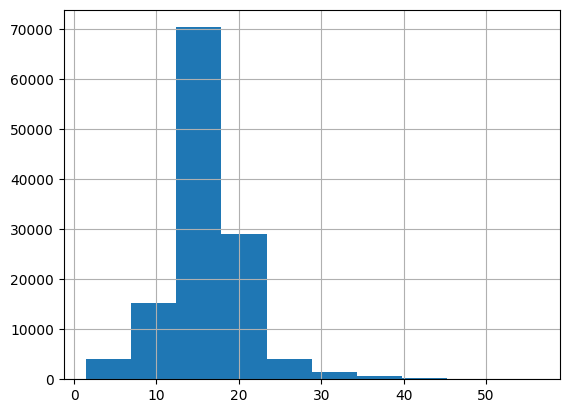

In [84]:
hgb_sd.hist()

In [85]:
np.percentile(hgb_sd, 1)

4.65217255427808

In [86]:
# Some SDs are super super small! They make anemia not computable
hgb_sd = hgb_sd.clip(lower=np.percentile(hgb_sd, 1))

In [87]:
zero_fort_anemia = calculate_anemia_from_mean_sd_hemoglobin(
    hgb_mean_zero_fort.rename("mean"), hgb_sd
)
zero_fort_anemia

severe  moderate  \
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   1               draw_0    0.030774  0.517762   
                                            draw_1    0.036863  0.586368   
                                            draw_2    0.038087  0.571666   
                                            draw_3    0.047926  0.514455   
                                            draw_4    0.030146  0.616099   
...                                                        ...       ...   
Male   95.0      125.000000 5               draw_495  0.060788  0.460675   
                                            draw_496  0.010930  0.458972   
                                            draw_497  0.143288  0.400872   
                                            draw_498  0.073412  0.426975   
                                            draw_499  0.072116  0.453019   

                                                          mild    anemic  
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0    0.289424  0.837961  
                                            draw_1    0.270411  0.893642  
                                            draw_2    0.271220  0.880974  
                                            draw_3    0.258663  0.821044  
                                            draw_4    0.273389  0.919634  
...                                                        ...       ...  
Male   95.0      125.000000 5               draw_495  0.403149  0.924613  
                                            draw_496  0.512972  0.982874  
                                            draw_497  0.307249  0.851408  
                                            draw_498  0.386972  0.887358  
                                            draw_499  0.387497  0.912631  

[125000 rows x 4 columns]

In [88]:
with_fort_anemia = calculate_anemia_from_mean_sd_hemoglobin(
    hgb_mean_with_fort.rename("mean"), hgb_sd
)
with_fort_anemia

severe  \
sex    age_start age_end    wealth_quintile draw     scenario                         
Female 0.0       0.019178   1               draw_0   intervention_100_nrv  0.030774   
                                                     intervention_25_nrv   0.030774   
                                            draw_1   intervention_100_nrv  0.036863   
                                                     intervention_25_nrv   0.036863   
                                            draw_2   intervention_100_nrv  0.038087   
...                                                                             ...   
Male   95.0      125.000000 5               draw_497 intervention_25_nrv   0.143288   
                                            draw_498 intervention_100_nrv  0.073412   
                                                     intervention_25_nrv   0.073412   
                                            draw_499 intervention_100_nrv  0.072116   
                                                     intervention_25_nrv   0.072116   

                                                                           moderate  \
sex    age_start age_end    wealth_quintile draw     scenario                         
Female 0.0       0.019178   1               draw_0   intervention_100_nrv  0.517762   
                                                     intervention_25_nrv   0.517762   
                                            draw_1   intervention_100_nrv  0.586368   
                                                     intervention_25_nrv   0.586368   
                                            draw_2   intervention_100_nrv  0.571666   
...                                                                             ...   
Male   95.0      125.000000 5               draw_497 intervention_25_nrv   0.400872   
                                            draw_498 intervention_100_nrv  0.426975   
                                                     intervention_25_nrv   0.426975   
                                            draw_499 intervention_100_nrv  0.453019   
                                                     intervention_25_nrv   0.453019   

                                                                               mild  \
sex    age_start age_end    wealth_quintile draw     scenario                         
Female 0.0       0.019178   1               draw_0   intervention_100_nrv  0.289424   
                                                     intervention_25_nrv   0.289424   
                                            draw_1   intervention_100_nrv  0.270411   
                                                     intervention_25_nrv   0.270411   
                                            draw_2   intervention_100_nrv  0.271220   
...                                                                             ...   
Male   95.0      125.000000 5               draw_497 intervention_25_nrv   0.307249   
                                            draw_498 intervention_100_nrv  0.386972   
                                                     intervention_25_nrv   0.386972   
                                            draw_499 intervention_100_nrv  0.387497   
                                                     intervention_25_nrv   0.387497   

                                                                             anemic  
sex    age_start age_end    wealth_quintile draw     scenario                        
Female 0.0       0.019178   1               draw_0   intervention_100_nrv  0.837961  
                                                     intervention_25_nrv   0.837961  
                                            draw_1   intervention_100_nrv  0.893642  
                                                     intervention_25_nrv   0.893642  
                                            draw_2   intervention_100_nrv  0.880974  
...                                                                            

In [89]:
total_population_anemia = calculate_anemia_from_mean_sd_hemoglobin(hgb_mean, hgb_sd)
total_population_anemia

severe  moderate  \
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   1               draw_0    0.030774  0.517762   
                                            draw_1    0.036863  0.586368   
                                            draw_2    0.038087  0.571666   
                                            draw_3    0.047926  0.514455   
                                            draw_4    0.030146  0.616099   
...                                                        ...       ...   
Male   95.0      125.000000 5               draw_495  0.060788  0.460675   
                                            draw_496  0.010930  0.458972   
                                            draw_497  0.143288  0.400872   
                                            draw_498  0.073412  0.426975   
                                            draw_499  0.072116  0.453019   

                                                          mild    anemic  
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0    0.289424  0.837961  
                                            draw_1    0.270411  0.893642  
                                            draw_2    0.271220  0.880974  
                                            draw_3    0.258663  0.821044  
                                            draw_4    0.273389  0.919634  
...                                                        ...       ...  
Male   95.0      125.000000 5               draw_495  0.403149  0.924613  
                                            draw_496  0.512972  0.982874  
                                            draw_497  0.307249  0.851408  
                                            draw_498  0.386972  0.887358  
                                            draw_499  0.387497  0.912631  

[125000 rows x 4 columns]

In [90]:
# NOTE: Here, we assume everyone is folate-responsive, instead of splitting this effect into
# a bigger effect among the folate-responsive and 0 among the non-

In [91]:
baseline_anemia = zero_fort_anemia
# TODO: If there were baseline coverage, we'd need to know
# its concentration!
# (
#     zero_fort_anemia.mul(
#         (1 - effective_coverage_baseline), axis=0
#     )
#     + with_fort_anemia.mul(
#         effective_coverage_baseline, axis=0
#     )
# )
baseline_anemia

severe  moderate  \
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   1               draw_0    0.030774  0.517762   
                                            draw_1    0.036863  0.586368   
                                            draw_2    0.038087  0.571666   
                                            draw_3    0.047926  0.514455   
                                            draw_4    0.030146  0.616099   
...                                                        ...       ...   
Male   95.0      125.000000 5               draw_495  0.060788  0.460675   
                                            draw_496  0.010930  0.458972   
                                            draw_497  0.143288  0.400872   
                                            draw_498  0.073412  0.426975   
                                            draw_499  0.072116  0.453019   

                                                          mild    anemic  
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0    0.289424  0.837961  
                                            draw_1    0.270411  0.893642  
                                            draw_2    0.271220  0.880974  
                                            draw_3    0.258663  0.821044  
                                            draw_4    0.273389  0.919634  
...                                                        ...       ...  
Male   95.0      125.000000 5               draw_495  0.403149  0.924613  
                                            draw_496  0.512972  0.982874  
                                            draw_497  0.307249  0.851408  
                                            draw_498  0.386972  0.887358  
                                            draw_499  0.387497  0.912631  

[125000 rows x 4 columns]

In [92]:
(baseline_anemia - total_population_anemia).describe()

,severe,moderate,mild,anemic
count,125000.0,125000.0,125000.0,125000.0
mean,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0


In [93]:
(
    baseline_anemia.loc[example_tuple].mean()
    - with_fort_anemia.loc[example_tuple].mean()
) / baseline_anemia.loc[example_tuple].mean()

severe      0.140215
moderate    0.125720
mild        0.073273
anemic      0.103928
dtype: float64

In [94]:
zero_fort_anemia

severe  moderate  \
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   1               draw_0    0.030774  0.517762   
                                            draw_1    0.036863  0.586368   
                                            draw_2    0.038087  0.571666   
                                            draw_3    0.047926  0.514455   
                                            draw_4    0.030146  0.616099   
...                                                        ...       ...   
Male   95.0      125.000000 5               draw_495  0.060788  0.460675   
                                            draw_496  0.010930  0.458972   
                                            draw_497  0.143288  0.400872   
                                            draw_498  0.073412  0.426975   
                                            draw_499  0.072116  0.453019   

                                                          mild    anemic  
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0    0.289424  0.837961  
                                            draw_1    0.270411  0.893642  
                                            draw_2    0.271220  0.880974  
                                            draw_3    0.258663  0.821044  
                                            draw_4    0.273389  0.919634  
...                                                        ...       ...  
Male   95.0      125.000000 5               draw_495  0.403149  0.924613  
                                            draw_496  0.512972  0.982874  
                                            draw_497  0.307249  0.851408  
                                            draw_498  0.386972  0.887358  
                                            draw_499  0.387497  0.912631  

[125000 rows x 4 columns]

In [95]:
intervention_anemia = zero_fort_anemia.mul(
    (1 - effective_coverage_intervention),
    axis=0,
) + with_fort_anemia.mul(effective_coverage_intervention, axis=0)
intervention_anemia

severe  \
sex    age_start age_end    wealth_quintile draw    scenario                         
Female 0.0       0.019178   1               draw_0  intervention_100_nrv  0.030774   
                                                    intervention_25_nrv   0.030774   
                                            draw_1  intervention_100_nrv  0.036863   
                                                    intervention_25_nrv   0.036863   
                                            draw_10 intervention_100_nrv  0.024093   
...                                                                            ...   
Male   95.0      125.000000 5               draw_97 intervention_25_nrv   0.048469   
                                            draw_98 intervention_100_nrv  0.091533   
                                                    intervention_25_nrv   0.091533   
                                            draw_99 intervention_100_nrv  0.029786   
                                                    intervention_25_nrv   0.029786   

                                                                          moderate  \
sex    age_start age_end    wealth_quintile draw    scenario                         
Female 0.0       0.019178   1               draw_0  intervention_100_nrv  0.517762   
                                                    intervention_25_nrv   0.517762   
                                            draw_1  intervention_100_nrv  0.586368   
                                                    intervention_25_nrv   0.586368   
                                            draw_10 intervention_100_nrv  0.609304   
...                                                                            ...   
Male   95.0      125.000000 5               draw_97 intervention_25_nrv   0.439003   
                                            draw_98 intervention_100_nrv  0.449897   
                                                    intervention_25_nrv   0.449897   
                                            draw_99 intervention_100_nrv  0.394153   
                                                    intervention_25_nrv   0.394153   

                                                                              mild  \
sex    age_start age_end    wealth_quintile draw    scenario                         
Female 0.0       0.019178   1               draw_0  intervention_100_nrv  0.289424   
                                                    intervention_25_nrv   0.289424   
                                            draw_1  intervention_100_nrv  0.270411   
                                                    intervention_25_nrv   0.270411   
                                            draw_10 intervention_100_nrv  0.287936   
...                                                                            ...   
Male   95.0      125.000000 5               draw_97 intervention_25_nrv   0.429160   
                                            draw_98 intervention_100_nrv  0.362407   
                                                    intervention_25_nrv   0.362407   
                                            draw_99 intervention_100_nrv  0.480719   
                                                    intervention_25_nrv   0.480719   

                                                                            anemic  
sex    age_start age_end    wealth_quintile draw    scenario                        
Female 0.0       0.019178   1               draw_0  intervention_100_nrv  0.837961  
                                                    intervention_25_nrv   0.837961  
                                            draw_1  intervention_100_nrv  0.893642  
                                                    intervention_25_nrv   0.893642  
                                            draw_10 intervention_100_nrv  0.921333  
...                                                                            ...  
Male   95.0      125.000000 5          

In [96]:
from lsff_utils.hemoglobin_distribution import hemoglobin_pdf_from_mean_sd

In [97]:
total_population_pdf = hemoglobin_pdf_from_mean_sd(
    np.array([hgb_mean.loc[example_tuple].mean()]),
    np.array([hgb_sd.loc[example_tuple].mean()]),
)
total_population_pdf

<function lsff_utils.hemoglobin_distribution.hemoglobin_pdf_from_mean_sd.<locals>.pdf(x)>

In [98]:
zero_fort_pdf = hemoglobin_pdf_from_mean_sd(
    np.array([hgb_mean_zero_fort.loc[example_tuple].mean()]),
    np.array([hgb_sd.loc[example_tuple].mean()]),
)
zero_fort_pdf

<function lsff_utils.hemoglobin_distribution.hemoglobin_pdf_from_mean_sd.<locals>.pdf(x)>

In [99]:
with_fort_pdf = hemoglobin_pdf_from_mean_sd(
    np.array([hgb_mean_with_fort.loc[example_tuple].mean()]),
    np.array([hgb_sd.loc[example_tuple].mean()]),
)
with_fort_pdf

<function lsff_utils.hemoglobin_distribution.hemoglobin_pdf_from_mean_sd.<locals>.pdf(x)>

In [100]:
def baseline_pdf(x):
    effective_covered = effective_coverage_baseline.loc[example_tuple]
    return (
        zero_fort_pdf(x) * (1 - effective_covered)
        + with_fort_pdf(x) * effective_covered
    )

In [101]:
def intervention_pdf(x):
    effective_covered = effective_coverage_intervention.loc[example_tuple]
    return (
        zero_fort_pdf(x) * (1 - effective_covered)
        + with_fort_pdf(x) * effective_covered
    )

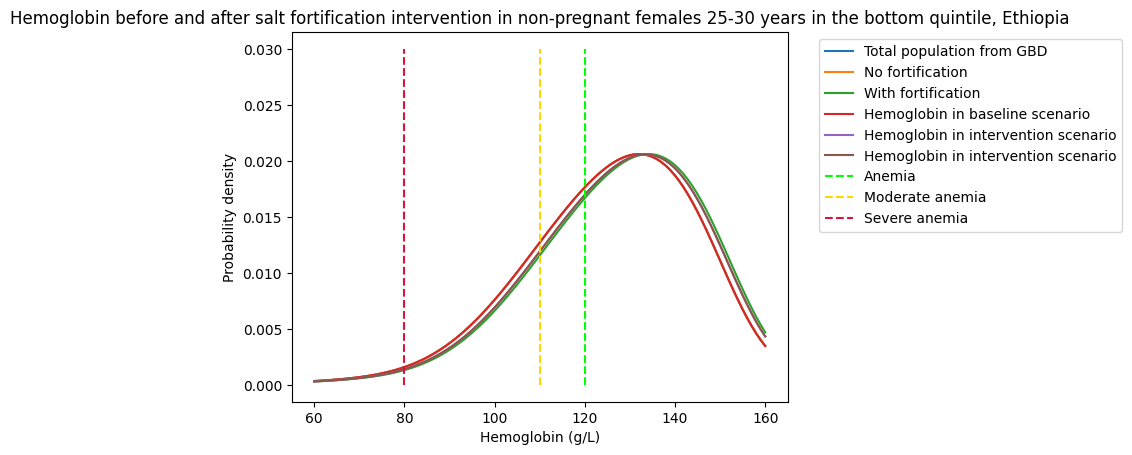

In [102]:
import matplotlib.pyplot as plt

x_values = np.linspace(60, 160, 100)
with np.errstate(under="ignore"):
    plt.plot(
        x_values,
        [total_population_pdf(x) for x in x_values],
        label="Total population from GBD",
    )
    plt.plot(
        x_values,
        [zero_fort_pdf(x) for x in x_values],
        label="No fortification",
    )
    plt.plot(
        x_values,
        [with_fort_pdf(x) for x in x_values],
        label="With fortification",
    )
    plt.plot(
        x_values,
        [baseline_pdf(x) for x in x_values],
        label="Hemoglobin in baseline scenario",
    )
    plt.plot(
        x_values,
        [intervention_pdf(x) for x in x_values],
        label="Hemoglobin in intervention scenario",
    )
    plt.vlines(
        thresholds.loc[
            (example_sex, example_age_start, example_age_end, 0)
        ].hgb_upper_mild,
        0,
        0.03,
        linestyles="dashed",
        label="Anemia",
        color="lime",
    )
    plt.vlines(
        thresholds.loc[
            (example_sex, example_age_start, example_age_end, 0)
        ].hgb_upper_moderate,
        0,
        0.03,
        linestyles="dashed",
        label="Moderate anemia",
        color="gold",
    )
    plt.vlines(
        thresholds.loc[
            (example_sex, example_age_start, example_age_end, 0)
        ].hgb_upper_severe,
        0,
        0.03,
        linestyles="dashed",
        label="Severe anemia",
        color="crimson",
    )
    plt.xlabel("Hemoglobin (g/L)")
    plt.ylabel("Probability density")
    plt.title(
        f"Hemoglobin before and after {vehicle} fortification intervention in non-pregnant females 25-30 years in the bottom quintile, {location.title()}"
    )
    plt.legend(bbox_to_anchor=(1.05, 1))

In [103]:
(baseline_anemia - intervention_anemia).sort_values("anemic")

severe  \
sex    age_start age_end   wealth_quintile draw     scenario                         
Female 90.0      95.000000 4               draw_109 intervention_100_nrv  0.000000   
                           3               draw_145 intervention_100_nrv  0.000000   
                                                    intervention_25_nrv   0.000000   
       0.0       0.019178  3               draw_219 intervention_100_nrv  0.000000   
                                                    intervention_25_nrv   0.000000   
...                                                                            ...   
       40.0      45.000000 3               draw_301 intervention_100_nrv  0.000688   
       25.0      30.000000 3               draw_161 intervention_100_nrv  0.000671   
       35.0      40.000000 3               draw_83  intervention_100_nrv  0.000714   
       45.0      50.000000 3               draw_236 intervention_100_nrv  0.000583   
       25.0      30.000000 3               draw_133 intervention_100_nrv  0.000825   

                                                                              moderate  \
sex    age_start age_end   wealth_quintile draw     scenario                             
Female 90.0      95.000000 4               draw_109 intervention_100_nrv  0.000000e+00   
                           3               draw_145 intervention_100_nrv  2.775558e-17   
                                                    intervention_25_nrv   2.775558e-17   
       0.0       0.019178  3               draw_219 intervention_100_nrv  0.000000e+00   
                                                    intervention_25_nrv   0.000000e+00   
...                                                                                ...   
       40.0      45.000000 3               draw_301 intervention_100_nrv  2.597757e-02   
       25.0      30.000000 3               draw_161 intervention_100_nrv  2.597419e-02   
       35.0      40.000000 3               draw_83  intervention_100_nrv  2.730449e-02   
       45.0      50.000000 3               draw_236 intervention_100_nrv  2.547131e-02   
       25.0      30.000000 3               draw_133 intervention_100_nrv  3.014974e-02   

                                                                              mild  \
sex    age_start age_end   wealth_quintile draw     scenario                         
Female 90.0      95.000000 4               draw_109 intervention_100_nrv  0.000000   
                           3               draw_145 intervention_100_nrv  0.000000   
                                                    intervention_25_nrv   0.000000   
       0.0       0.019178  3               draw_219 intervention_100_nrv  0.000000   
                                                    intervention_25_nrv   0.000000   
...                                                                            ...   
       40.0      45.000000 3               draw_301 intervention_100_nrv  0.038223   
       25.0      30.000000 3               draw_161 intervention_100_nrv  0.038741   
       35.0      40.000000 3               draw_83  intervention_100_nrv  0.038980   
       45.0      50.000000 3               draw_236 intervention_100_nrv  0.041209   
       25.0      30.000000 3               draw_133 intervention_100_nrv  0.038855   

                                                                                anemic  
sex    age_start age_end   wealth_quintile draw     scenario                            
Female 90.0      95.000000 4               draw_109 intervention_100_nrv -1.110223e-16  
                           3               draw_145 intervention_100_nrv -1.110223e-16  
                                                    intervention_25_nrv  -1.110223e-16  
       0.0       0.019178  3               draw_219 intervention_100_nrv -1.110223e-16  
                                                    intervention_25_nrv  -1.110223e-16  
...                                         

In [104]:
def anemia_to_yld_rates(anemia):
    disability_weights = pd.read_hdf(
        "/mnt/team/simulation_science/costeffectiveness/auxiliary_data/GBD_2021/02_processed_data/disability_weight/sequela/all/all.hdf"
    )
    disability_weights = (
        disability_weights[
            disability_weights.healthstate.isin(
                ["anemia_mild", "anemia_mod", "anemia_sev"]
            )
        ]
        .set_index("healthstate")
        .filter(like="draw_")
    )
    disability_weights.columns.name = "draw"
    disability_weights = (
        disability_weights.stack().rename("disability_weight").reset_index()
    )
    display(disability_weights)

    orig_index = anemia.index
    anemia = (
        anemia.reset_index()
        .merge(
            disability_weights[disability_weights.healthstate == "anemia_mild"][
                ["draw", "disability_weight"]
            ].rename(columns={"disability_weight": "mild_dw"}),
            validate="m:1",
        )
        .merge(
            disability_weights[disability_weights.healthstate == "anemia_mod"][
                ["draw", "disability_weight"]
            ].rename(columns={"disability_weight": "moderate_dw"}),
            validate="m:1",
        )
        .merge(
            disability_weights[disability_weights.healthstate == "anemia_sev"][
                ["draw", "disability_weight"]
            ].rename(columns={"disability_weight": "severe_dw"}),
            validate="m:1",
        )
    )

    anemia["mild_yld_rate"] = anemia.mild * anemia.mild_dw
    anemia["moderate_yld_rate"] = anemia.moderate * anemia.moderate_dw
    anemia["severe_yld_rate"] = anemia.severe * anemia.severe_dw
    anemia["anemic_yld_rate"] = (
        anemia["mild_yld_rate"]
        + anemia["moderate_yld_rate"]
        + anemia["severe_yld_rate"]
    )

    return anemia.set_index(orig_index.names).filter(like="yld_rate")

In [105]:
zero_fort_anemia_yld_rates = anemia_to_yld_rates(zero_fort_anemia)
zero_fort_anemia_yld_rates

,healthstate,draw,disability_weight
0,anemia_mild,draw_0,0.002420
1,anemia_mild,draw_1,0.003172
2,anemia_mild,draw_2,0.002644
3,anemia_mild,draw_3,0.003085
4,anemia_mild,draw_4,0.001845
...,...,...,...
2995,anemia_sev,draw_995,0.174969
2996,anemia_sev,draw_996,0.086798
2997,anemia_sev,draw_997,0.131996
2998,anemia_sev,draw_998,0.124427


mild_yld_rate  \
sex    age_start age_end    wealth_quintile draw                      
Female 0.0       0.019178   1               draw_0         0.000701   
                            2               draw_0         0.000850   
                            3               draw_0         0.000866   
                            4               draw_0         0.000945   
                            5               draw_0         0.000907   
...                                                             ...   
Male   95.0      125.000000 1               draw_499       0.000901   
                            2               draw_499       0.001050   
                            3               draw_499       0.001089   
                            4               draw_499       0.001136   
                            5               draw_499       0.001225   

                                                      moderate_yld_rate  \
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0             0.030704   
                            2               draw_0             0.024634   
                            3               draw_0             0.018960   
                            4               draw_0             0.022280   
                            5               draw_0             0.014760   
...                                                                 ...   
Male   95.0      125.000000 1               draw_499           0.018270   
                            2               draw_499           0.019421   
                            3               draw_499           0.019406   
                            4               draw_499           0.019374   
                            5               draw_499           0.019084   

                                                      severe_yld_rate  \
sex    age_start age_end    wealth_quintile draw                        
Female 0.0       0.019178   1               draw_0           0.006122   
                            2               draw_0           0.002313   
                            3               draw_0           0.001403   
                            4               draw_0           0.001314   
                            5               draw_0           0.000719   
...                                                               ...   
Male   95.0      125.000000 1               draw_499         0.018862   
                            2               draw_499         0.012613   
                            3               draw_499         0.011348   
                            4               draw_499         0.009949   
                            5               draw_499         0.007697   

                                                      anemic_yld_rate  
sex    age_start age_end    wealth_quintile draw                       
Female 0.0       0.019178   1               draw_0           0.037526  
                            2               draw_0           0.027796  
                            3               draw_0           0.021228  
                            4               draw_0           0.024539  
                            5               draw_0           0.016386  
...                                                               ...  
Male   95.0      125.000000 1               draw_499         0.038032  
                            2               draw_499         0.033084  
                            3               draw_499         0.031844  
                            4               draw_499         0.030459  
                            5               draw_499         0.028006  

[125000 rows x 4 columns]

In [106]:
baseline_anemia_yld_rates = anemia_to_yld_rates(baseline_anemia)
baseline_anemia_yld_rates

,healthstate,draw,disability_weight
0,anemia_mild,draw_0,0.002420
1,anemia_mild,draw_1,0.003172
2,anemia_mild,draw_2,0.002644
3,anemia_mild,draw_3,0.003085
4,anemia_mild,draw_4,0.001845
...,...,...,...
2995,anemia_sev,draw_995,0.174969
2996,anemia_sev,draw_996,0.086798
2997,anemia_sev,draw_997,0.131996
2998,anemia_sev,draw_998,0.124427


mild_yld_rate  \
sex    age_start age_end    wealth_quintile draw                      
Female 0.0       0.019178   1               draw_0         0.000701   
                            2               draw_0         0.000850   
                            3               draw_0         0.000866   
                            4               draw_0         0.000945   
                            5               draw_0         0.000907   
...                                                             ...   
Male   95.0      125.000000 1               draw_499       0.000901   
                            2               draw_499       0.001050   
                            3               draw_499       0.001089   
                            4               draw_499       0.001136   
                            5               draw_499       0.001225   

                                                      moderate_yld_rate  \
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0             0.030704   
                            2               draw_0             0.024634   
                            3               draw_0             0.018960   
                            4               draw_0             0.022280   
                            5               draw_0             0.014760   
...                                                                 ...   
Male   95.0      125.000000 1               draw_499           0.018270   
                            2               draw_499           0.019421   
                            3               draw_499           0.019406   
                            4               draw_499           0.019374   
                            5               draw_499           0.019084   

                                                      severe_yld_rate  \
sex    age_start age_end    wealth_quintile draw                        
Female 0.0       0.019178   1               draw_0           0.006122   
                            2               draw_0           0.002313   
                            3               draw_0           0.001403   
                            4               draw_0           0.001314   
                            5               draw_0           0.000719   
...                                                               ...   
Male   95.0      125.000000 1               draw_499         0.018862   
                            2               draw_499         0.012613   
                            3               draw_499         0.011348   
                            4               draw_499         0.009949   
                            5               draw_499         0.007697   

                                                      anemic_yld_rate  
sex    age_start age_end    wealth_quintile draw                       
Female 0.0       0.019178   1               draw_0           0.037526  
                            2               draw_0           0.027796  
                            3               draw_0           0.021228  
                            4               draw_0           0.024539  
                            5               draw_0           0.016386  
...                                                               ...  
Male   95.0      125.000000 1               draw_499         0.038032  
                            2               draw_499         0.033084  
                            3               draw_499         0.031844  
                            4               draw_499         0.030459  
                            5               draw_499         0.028006  

[125000 rows x 4 columns]

In [107]:
(
    baseline_anemia_yld_rates.loc[("Female", 25, 30, 1)].mean()
    - anemia_to_yld_rates(with_fort_anemia).loc[("Female", 25, 30, 1)].mean()
) / baseline_anemia_yld_rates.loc[("Female", 25, 30, 1)].mean()

,healthstate,draw,disability_weight
0,anemia_mild,draw_0,0.002420
1,anemia_mild,draw_1,0.003172
2,anemia_mild,draw_2,0.002644
3,anemia_mild,draw_3,0.003085
4,anemia_mild,draw_4,0.001845
...,...,...,...
2995,anemia_sev,draw_995,0.174969
2996,anemia_sev,draw_996,0.086798
2997,anemia_sev,draw_997,0.131996
2998,anemia_sev,draw_998,0.124427


mild_yld_rate        0.073101
moderate_yld_rate    0.125648
severe_yld_rate      0.140198
anemic_yld_rate      0.126845
dtype: float64

In [108]:
intervention_anemia_yld_rates = anemia_to_yld_rates(intervention_anemia)
intervention_anemia_yld_rates

,healthstate,draw,disability_weight
0,anemia_mild,draw_0,0.002420
1,anemia_mild,draw_1,0.003172
2,anemia_mild,draw_2,0.002644
3,anemia_mild,draw_3,0.003085
4,anemia_mild,draw_4,0.001845
...,...,...,...
2995,anemia_sev,draw_995,0.174969
2996,anemia_sev,draw_996,0.086798
2997,anemia_sev,draw_997,0.131996
2998,anemia_sev,draw_998,0.124427


mild_yld_rate  \
sex    age_start age_end    wealth_quintile draw    scenario                              
Female 0.0       0.019178   1               draw_0  intervention_100_nrv       0.000701   
                                                    intervention_25_nrv        0.000701   
                            2               draw_0  intervention_100_nrv       0.000850   
                                                    intervention_25_nrv        0.000850   
                            3               draw_0  intervention_100_nrv       0.000866   
...                                                                                 ...   
Male   95.0      125.000000 3               draw_99 intervention_25_nrv        0.001790   
                            4               draw_99 intervention_100_nrv       0.001870   
                                                    intervention_25_nrv        0.001870   
                            5               draw_99 intervention_100_nrv       0.002019   
                                                    intervention_25_nrv        0.002019   

                                                                          moderate_yld_rate  \
sex    age_start age_end    wealth_quintile draw    scenario                                  
Female 0.0       0.019178   1               draw_0  intervention_100_nrv           0.030704   
                                                    intervention_25_nrv            0.030704   
                            2               draw_0  intervention_100_nrv           0.024634   
                                                    intervention_25_nrv            0.024634   
                            3               draw_0  intervention_100_nrv           0.018960   
...                                                                                     ...   
Male   95.0      125.000000 3               draw_99 intervention_25_nrv            0.018068   
                            4               draw_99 intervention_100_nrv           0.017569   
                                                    intervention_25_nrv            0.017569   
                            5               draw_99 intervention_100_nrv           0.016429   
                                                    intervention_25_nrv            0.016429   

                                                                          severe_yld_rate  \
sex    age_start age_end    wealth_quintile draw    scenario                                
Female 0.0       0.019178   1               draw_0  intervention_100_nrv         0.006122   
                                                    intervention_25_nrv          0.006122   
                            2               draw_0  intervention_100_nrv         0.002313   
                                                    intervention_25_nrv          0.002313   
                            3               draw_0  intervention_100_nrv         0.001403   
...                                                                                   ...   
Male   95.0      125.000000 3               draw_99 intervention_25_nrv          0.005974   
                            4               draw_99 intervention_100_nrv         0.004982   
                                                    intervention_25_nrv          0.004982   
                            5               draw_99 intervention_100_nrv         0.003538   
                                                    intervention_25_nrv          0.003538   

                                                                          anemic_yld_rate  
sex    age_start age_end    wealth_quintile draw    scenario                               
Female 0.0       0.019178   1               draw_0  intervention_100_nrv         0.037526  
                                                    intervention_25_nrv          0.037526  
                            2               draw_0  intervention_100_nrv    

In [109]:
(baseline_anemia_yld_rates - intervention_anemia_yld_rates).sort_values(
    "anemic_yld_rate"
)

mild_yld_rate  \
sex    age_start age_end    wealth_quintile draw     scenario                              
Male   90.000000 95.000000  5               draw_52  intervention_100_nrv       0.000000   
                                                     intervention_25_nrv        0.000000   
       95.000000 125.000000 1               draw_131 intervention_100_nrv       0.000000   
                                                     intervention_25_nrv        0.000000   
       0.019178  0.076712   1               draw_249 intervention_100_nrv       0.000000   
...                                                                                  ...   
Female 30.000000 35.000000  1               draw_45  intervention_100_nrv       0.000128   
       20.000000 25.000000  1               draw_45  intervention_100_nrv       0.000169   
       35.000000 40.000000  1               draw_45  intervention_100_nrv       0.000205   
       40.000000 45.000000  1               draw_45  intervention_100_nrv       0.000178   
       25.000000 30.000000  1               draw_45  intervention_100_nrv       0.000198   

                                                                           moderate_yld_rate  \
sex    age_start age_end    wealth_quintile draw     scenario                                  
Male   90.000000 95.000000  5               draw_52  intervention_100_nrv      -6.938894e-18   
                                                     intervention_25_nrv       -6.938894e-18   
       95.000000 125.000000 1               draw_131 intervention_100_nrv       0.000000e+00   
                                                     intervention_25_nrv        0.000000e+00   
       0.019178  0.076712   1               draw_249 intervention_100_nrv       0.000000e+00   
...                                                                                      ...   
Female 30.000000 35.000000  1               draw_45  intervention_100_nrv       2.465701e-03   
       20.000000 25.000000  1               draw_45  intervention_100_nrv       2.671882e-03   
       35.000000 40.000000  1               draw_45  intervention_100_nrv       2.894953e-03   
       40.000000 45.000000  1               draw_45  intervention_100_nrv       2.846516e-03   
       25.000000 30.000000  1               draw_45  intervention_100_nrv       3.020407e-03   

                                                                           severe_yld_rate  \
sex    age_start age_end    wealth_quintile draw     scenario                                
Male   90.000000 95.000000  5               draw_52  intervention_100_nrv     0.000000e+00   
                                                     intervention_25_nrv      0.000000e+00   
       95.000000 125.000000 1               draw_131 intervention_100_nrv    -6.938894e-18   
                                                     intervention_25_nrv     -6.938894e-18   
       0.019178  0.076712   1               draw_249 intervention_100_nrv    -6.938894e-18   
...                                                                                    ...   
Female 30.000000 35.000000  1               draw_45  intervention_100_nrv     6.755075e-04   
       20.000000 25.000000  1               draw_45  intervention_100_nrv     4.789912e-04   
       35.000000 40.000000  1               draw_45  intervention_100_nrv     3.899803e-04   
       40.000000 45.000000  1               draw_45  intervention_100_nrv     4.812058e-04   
       25.000000 30.000000  1               draw_45  intervention_100_nrv     4.376024e-04   

                                                                           anemic_yld_rate  
sex    age_start age_end    wealth_quintile draw     scenario                               
Male   90.000000 95.000000  5               draw_52  intervention_100_nrv    -1.387779e-17  
                                                     intervention_25_nrv     -1.387779e-17  
       95.000000 125.000000 1     

In [110]:
(baseline_anemia_yld_rates - intervention_anemia_yld_rates).anemic_yld_rate.describe()

count    2.500000e+05
mean     1.236098e-04
std      3.374396e-04
min     -1.387779e-17
25%      0.000000e+00
50%      0.000000e+00
75%      4.408977e-05
max      3.655808e-03
Name: anemic_yld_rate, dtype: float64

In [111]:
assert (
    ((baseline_anemia_yld_rates - intervention_anemia_yld_rates).anemic_yld_rate >= 0)
    | np.isclose(
        (baseline_anemia_yld_rates - intervention_anemia_yld_rates).anemic_yld_rate, 0
    )
).all()

In [112]:
zero_fort_ylds = (
    zero_fort_anemia_yld_rates.anemic_yld_rate.unstack("draw").mean(axis=1)
    * non_pregnant_pop
)
zero_fort_ylds

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  273.390021
                               2                  191.851401
                               3                  139.900681
                               4                  147.088093
                               5                   79.362233
                                                     ...    
Male    95.0       125.000000  1                   30.336412
                               2                   27.064315
                               3                   26.890065
                               4                   27.038454
                               5                   21.509160
Length: 250, dtype: float64

In [113]:
baseline_ylds = (
    baseline_anemia_yld_rates.anemic_yld_rate.unstack("draw").mean(axis=1)
    * non_pregnant_pop
)
baseline_ylds

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  273.390021
                               2                  191.851401
                               3                  139.900681
                               4                  147.088093
                               5                   79.362233
                                                     ...    
Male    95.0       125.000000  1                   30.336412
                               2                   27.064315
                               3                   26.890065
                               4                   27.038454
                               5                   21.509160
Length: 250, dtype: float64

In [114]:
intervention_ylds = (
    intervention_anemia_yld_rates.anemic_yld_rate.unstack("draw").mean(axis=1)
    * non_pregnant_pop
)
intervention_ylds

sex     age_start  age_end     wealth_quintile  scenario            
Female  0.0        0.019178    1                intervention_100_nrv    273.390021
                                                intervention_25_nrv     273.390021
                               2                intervention_100_nrv    191.851401
                                                intervention_25_nrv     191.851401
                               3                intervention_100_nrv    139.900681
                                                                           ...    
Male    95.0       125.000000  3                intervention_25_nrv      26.890065
                               4                intervention_100_nrv     27.038454
                                                intervention_25_nrv      27.038454
                               5                intervention_100_nrv     21.509160
                                                intervention_25_nrv      21.509160
Length: 500, dtype

In [115]:
(
    baseline_ylds.loc[("Female", 25, 30, 1)]
    - intervention_ylds.loc[("Female", 25, 30, 1)]
)

scenario
intervention_100_nrv    1063.971907
intervention_25_nrv      283.769613
dtype: float64

In [116]:
(
    baseline_ylds.groupby(["wealth_quintile"]).sum()
    - intervention_ylds.groupby(["wealth_quintile", "scenario"]).sum()
)

wealth_quintile  scenario            
1                intervention_100_nrv    9579.560738
                 intervention_25_nrv     2577.499616
2                intervention_100_nrv    7556.126447
                 intervention_25_nrv     2092.952703
3                intervention_100_nrv    8085.542072
                 intervention_25_nrv     2287.314210
4                intervention_100_nrv    3240.305919
                 intervention_25_nrv      852.669749
5                intervention_100_nrv    2379.898399
                 intervention_25_nrv      619.396597
dtype: float64

In [117]:
ylds = pd.concat(
    [
        zero_fort_ylds.rename("value").reset_index().assign(scenario="zero"),
        baseline_ylds.rename("value").reset_index().assign(scenario="baseline"),
        intervention_ylds.rename("value").reset_index(),
    ],
    ignore_index=True,
)
ylds

,sex,age_start,age_end,wealth_quintile,value,scenario
0,Female,0.0,0.019178,1,273.390021,zero
1,Female,0.0,0.019178,2,191.851401,zero
2,Female,0.0,0.019178,3,139.900681,zero
3,Female,0.0,0.019178,4,147.088093,zero
4,Female,0.0,0.019178,5,79.362233,zero
...,...,...,...,...,...,...
995,Male,95.0,125.000000,3,26.890065,intervention_25_nrv
996,Male,95.0,125.000000,4,27.038454,intervention_100_nrv
997,Male,95.0,125.000000,4,27.038454,intervention_25_nrv
998,Male,95.0,125.000000,5,21.509160,intervention_100_nrv


In [118]:
results_dir = f"./results/{vehicle.lower()}/{location.lower()}"

In [119]:
path = f"{results_dir}/ylds.parquet"
pathlib.Path(path).parent.mkdir(exist_ok=True, parents=True)
ylds.to_parquet(path)

In [120]:
zero_fort_anemia_prevalence = zero_fort_anemia["anemic"].unstack("draw").mean(axis=1)
zero_fort_anemia_prevalence

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  0.887070
                               2                  0.841549
                               3                  0.758522
                               4                  0.840025
                               5                  0.707691
                                                    ...   
Male    95.0       125.000000  1                  0.906081
                               2                  0.918218
                               3                  0.917855
                               4                  0.918135
                               5                  0.917428
Length: 250, dtype: float64

In [121]:
baseline_anemia_prevalence = baseline_anemia["anemic"].unstack("draw").mean(axis=1)
baseline_anemia_prevalence

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  0.887070
                               2                  0.841549
                               3                  0.758522
                               4                  0.840025
                               5                  0.707691
                                                    ...   
Male    95.0       125.000000  1                  0.906081
                               2                  0.918218
                               3                  0.917855
                               4                  0.918135
                               5                  0.917428
Length: 250, dtype: float64

In [122]:
zero_fort_anemia_cases = zero_fort_anemia_prevalence.mul(non_pregnant_pop, axis=0)
zero_fort_anemia_cases

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  6856.456429
                               2                  5912.792449
                               3                  5038.410138
                               4                  5003.933511
                               5                  3379.055953
                                                     ...     
Male    95.0       125.000000  1                   597.631703
                               2                   633.661587
                               3                   657.450107
                               4                   695.852236
                               5                   609.373019
Length: 250, dtype: float64

In [123]:
zero_fort_anemia_cases.sum() / non_pregnant_pop.sum()

0.2554555458017435

In [124]:
baseline_anemia_cases = baseline_anemia_prevalence.mul(non_pregnant_pop, axis=0)
baseline_anemia_cases

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  6856.456429
                               2                  5912.792449
                               3                  5038.410138
                               4                  5003.933511
                               5                  3379.055953
                                                     ...     
Male    95.0       125.000000  1                   597.631703
                               2                   633.661587
                               3                   657.450107
                               4                   695.852236
                               5                   609.373019
Length: 250, dtype: float64

In [125]:
baseline_anemia_cases.sum() / non_pregnant_pop.sum()

0.2554555458017435

In [126]:
baseline_anemia_cases.groupby(["wealth_quintile"]).sum() / non_pregnant_pop.groupby(
    ["wealth_quintile"]
).sum()

wealth_quintile
1    0.388741
2    0.278881
3    0.236579
4    0.221689
5    0.160736
dtype: float64

In [127]:
intervention_anemia_prevalence = (
    intervention_anemia["anemic"].unstack("draw").mean(axis=1)
)
intervention_anemia_prevalence

sex     age_start  age_end     wealth_quintile  scenario            
Female  0.0        0.019178    1                intervention_100_nrv    0.887070
                                                intervention_25_nrv     0.887070
                               2                intervention_100_nrv    0.841549
                                                intervention_25_nrv     0.841549
                               3                intervention_100_nrv    0.758522
                                                                          ...   
Male    95.0       125.000000  3                intervention_25_nrv     0.917855
                               4                intervention_100_nrv    0.918135
                                                intervention_25_nrv     0.918135
                               5                intervention_100_nrv    0.917428
                                                intervention_25_nrv     0.917428
Length: 500, dtype: float64

In [128]:
total_population_anemia_prevalence = (
    total_population_anemia["anemic"].unstack("draw").mean(axis=1)
)
total_population_anemia_prevalence

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  0.887070
                               2                  0.841549
                               3                  0.758522
                               4                  0.840025
                               5                  0.707691
                                                    ...   
Male    95.0       125.000000  1                  0.906081
                               2                  0.918218
                               3                  0.917855
                               4                  0.918135
                               5                  0.917428
Length: 250, dtype: float64

In [129]:
total_population_anemia_cases = total_population_anemia_prevalence.mul(
    non_pregnant_pop, axis=0
)
total_population_anemia_cases

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  6856.456429
                               2                  5912.792449
                               3                  5038.410138
                               4                  5003.933511
                               5                  3379.055953
                                                     ...     
Male    95.0       125.000000  1                   597.631703
                               2                   633.661587
                               3                   657.450107
                               4                   695.852236
                               5                   609.373019
Length: 250, dtype: float64

In [130]:
total_population_anemia_cases.sum() / non_pregnant_pop.sum()

0.2554555458017435

In [131]:
anemia_prevalence = pd.concat(
    [
        zero_fort_anemia_prevalence.rename("value")
        .reset_index()
        .assign(scenario="zero"),
        baseline_anemia_prevalence.rename("value")
        .reset_index()
        .assign(scenario="baseline"),
        intervention_anemia_prevalence.rename("value").reset_index(),
    ],
    ignore_index=True,
)
anemia_prevalence

,sex,age_start,age_end,wealth_quintile,value,scenario
0,Female,0.0,0.019178,1,0.887070,zero
1,Female,0.0,0.019178,2,0.841549,zero
2,Female,0.0,0.019178,3,0.758522,zero
3,Female,0.0,0.019178,4,0.840025,zero
4,Female,0.0,0.019178,5,0.707691,zero
...,...,...,...,...,...,...
995,Male,95.0,125.000000,3,0.917855,intervention_25_nrv
996,Male,95.0,125.000000,4,0.918135,intervention_100_nrv
997,Male,95.0,125.000000,4,0.918135,intervention_25_nrv
998,Male,95.0,125.000000,5,0.917428,intervention_100_nrv


In [132]:
path = f"{results_dir}/anemia_prevalence.parquet"
pathlib.Path(path).parent.mkdir(exist_ok=True, parents=True)
anemia_prevalence.to_parquet(path)

In [133]:
intervention_anemia_cases = intervention_anemia_prevalence.mul(non_pregnant_pop, axis=0)
intervention_anemia_cases

sex     age_start  age_end     wealth_quintile  scenario            
Female  0.0        0.019178    1                intervention_100_nrv    6856.456429
                                                intervention_25_nrv     6856.456429
                               2                intervention_100_nrv    5912.792449
                                                intervention_25_nrv     5912.792449
                               3                intervention_100_nrv    5038.410138
                                                                           ...     
Male    95.0       125.000000  3                intervention_25_nrv      657.450107
                               4                intervention_100_nrv     695.852236
                                                intervention_25_nrv      695.852236
                               5                intervention_100_nrv     609.373019
                                                intervention_25_nrv      609.373019
Length:

In [134]:
intervention_anemia_cases.groupby("scenario").sum() / non_pregnant_pop.sum()

scenario
intervention_100_nrv    0.244162
intervention_25_nrv     0.252440
dtype: float64

In [135]:
intervention_anemia_cases.groupby(
    ["scenario", "wealth_quintile"]
).sum() / non_pregnant_pop.groupby(["wealth_quintile"]).sum()

scenario              wealth_quintile
intervention_100_nrv  1                  0.374504
                      2                  0.264318
                      3                  0.220264
                      4                  0.214969
                      5                  0.155581
intervention_25_nrv   1                  0.385015
                      2                  0.274952
                      3                  0.232093
                      4                  0.219941
                      5                  0.159404
dtype: float64

In [136]:
(
    baseline_anemia_cases.groupby(["wealth_quintile"]).sum()
    - intervention_anemia_cases.groupby(["wealth_quintile"]).sum()
).map(lambda x: f"{round(x):,.0f}")

wealth_quintile
1    -7,551,366
2    -5,392,505
3    -4,506,569
4    -4,534,260
5    -3,399,237
dtype: object

In [137]:
anemia_cases = pd.concat(
    [
        zero_fort_anemia_cases.rename("value").reset_index().assign(scenario="zero"),
        baseline_anemia_cases.rename("value").reset_index().assign(scenario="baseline"),
        intervention_anemia_cases.rename("value").reset_index(),
    ],
    ignore_index=True,
)
anemia_cases

,sex,age_start,age_end,wealth_quintile,value,scenario
0,Female,0.0,0.019178,1,6856.456429,zero
1,Female,0.0,0.019178,2,5912.792449,zero
2,Female,0.0,0.019178,3,5038.410138,zero
3,Female,0.0,0.019178,4,5003.933511,zero
4,Female,0.0,0.019178,5,3379.055953,zero
...,...,...,...,...,...,...
995,Male,95.0,125.000000,3,657.450107,intervention_25_nrv
996,Male,95.0,125.000000,4,695.852236,intervention_100_nrv
997,Male,95.0,125.000000,4,695.852236,intervention_25_nrv
998,Male,95.0,125.000000,5,609.373019,intervention_100_nrv


In [138]:
path = f"{results_dir}/anemia_cases.parquet"
pathlib.Path(path).parent.mkdir(exist_ok=True, parents=True)
anemia_cases.to_parquet(path)

In [139]:
anemia_cases.notnull().all()

sex                True
age_start          True
age_end            True
wealth_quintile    True
value              True
scenario           True
dtype: bool